<a href="https://colab.research.google.com/github/Crisperez517/Tesis/blob/main/TESIS_Simulaci%C3%B3n_Escenario_C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulación y Análisis de Riesgo en la Red de Frío para Vacunas
### Evaluación del Refrigerador Haier HBC-150 bajo Condiciones Críticas en Tuxtla Gutiérrez, Chiapas
### **Escenario C: Estrés Operativo y Contingencia**

**Programa:** Tesis para obtener el título de Licenciatura en Matemáticas Aplicadas

**Institución:** Facultad de Ciencias en Física y Matemáticas (FCFM), Benemérita  Universidad Autónoma de Chiapas (UNACH)

**Autor:** Cristóbal Pérez González

**Asesor:** Dr. Yofre Hernán García Gómez

---

### Descripción del Proyecto (Escenario C)
Este cuaderno es el tercer y más complejo módulo de la investigación. Su objetivo es cuantificar la vulnerabilidad integral de la red de frío durante **contingencias o cercos epidemiológicos**.

Bajo estas condiciones de estrés operativo, la afluencia masiva de pacientes agota rápidamente los termos auxiliares de las enfermeras, obligando a realizar viajes de resurtido imprevistos al equipo principal. Matemáticamente, este escenario implementa el **acoplamiento estocástico** entre la termodinámica y la logística: el exceso de aperturas aleatorias matutinas no solo inyecta ruido térmico severo al refrigerador, sino que dispara exponencialmente el consumo del inventario ($D_C(t) = D_{base} + (N_{resurtido}(t) \times D_{base})$), forzando a la red a reabastecerse masivamente mientras su inercia térmica se encuentra mermada por los cortes de luz.

### Metodología y Arquitectura del Código:
1. **Entorno Climático:** Modelado continuo del clima extremo de Tuxtla Gutiérrez (interpolación senoidal a intervalos de 5 minutos, con picos de calor a las 15:00 hrs).
2. **Infraestructura Eléctrica (CFE):** Simulación de interrupciones del suministro mediante un Proceso de Poisson No Homogéneo ($\lambda(t)$ estacional) y duraciones aleatorias Log-Normales.
3. **Termodinámica (SDE) de Alta Frecuencia:** Resolución de la Ecuación Diferencial Estocástica de Ornstein-Uhlenbeck ($\theta_{set} = 5^\circ\text{C}$) bajo *Regime-Switching*. Se modelan **dos ventanas activas del Proceso de Poisson Compuesto**: resurtido matutino ($\lambda_{mañana} = 0.4$ eventos/hr) y resguardo vespertino ($\lambda_{tarde} = 0.5$ eventos/hr). Cada apertura inyecta un choque de calor aleatorio derivado de una distribución Normal truncada ($\gamma_i \sim \max(0.16, \mathcal{N}(0.76, 0.20^2))$).
4. **Cinética de Degradación y Dinámica de Inventario Acoplada:** La integral de la Ecuación de Arrhenius ($>8^\circ\text{C}$) merma las vacunas sobrevivientes. El consumo logístico diario deja de ser determinista y se convierte en una variable aleatoria directamente dependiente del número de extracciones matutinas.
5. **Simulación de Montecarlo:** Bucle de **Montecarlo (5,000 trayectorias anuales)** para capturar el *Value at Risk (VaR)* y calcular los intervalos de predicción estadísticos que revelan el máximo impacto sobre la salud pública chiapaneca en escenarios de crisis.

---
*Instrucciones de uso: Ejecutar las celdas de forma secuencial. Las gráficas estáticas y métricas que se imprimen al final corresponden al análisis de riesgo bajo estrés extremo utilizado en el capítulo de simulación.*

## Celda 1: Procesamiento de la Serie de Tiempo y Función de Temperatura $T_{amb}(t)$

En esta primera sección preparamos el "motor temporal" y el entorno climático de nuestra simulación, basándonos en los registros meteorológicos reales de Tuxtla Gutiérrez para el año 2024.

1. **Calendario Logístico:** Extraemos los días de la semana y definimos los días festivos oficiales en México para el año 2024. Al combinar los fines de semana con los días festivos, creamos un arreglo de "días inhábiles". Esto es crucial prepararlo desde el inicio, ya que el resto de la simulación sabrá automáticamente que en estos días la clínica está cerrada, la demanda es cero y la puerta no se abre, afectando directamente la termodinámica del equipo.
2. **Clima y Función Determinista $T_{amb}(t)$:** Cargamos la temperatura promedio diaria ($T_{avg}$) desde nuestra base de datos. Dado que la Ecuación Diferencial Estocástica (EDE) requiere integración continua, construimos una malla de tiempo para cada intervalo de 5 minutos ($\Delta t = 5/60$). Para modelar el estrés térmico máximo durante el día, sobreponemos al promedio una onda senoidal con una amplitud térmica de $7^\circ\text{C}$ (simulando una diferencia típica de $14^\circ\text{C}$ entre la madrugada y la tarde). El argumento del coseno está desfasado para forzar matemáticamente que el pico absoluto de calor golpee al refrigerador exactamente a las 15:00 horas todos los días.
3. **Validación Gráfica:** Comparamos visualmente el vector de temperatura diaria base contra nuestra nueva función de temperatura continua a lo largo del día.

Pasos totales de simulación: 105408 iteraciones de 5 minutos.



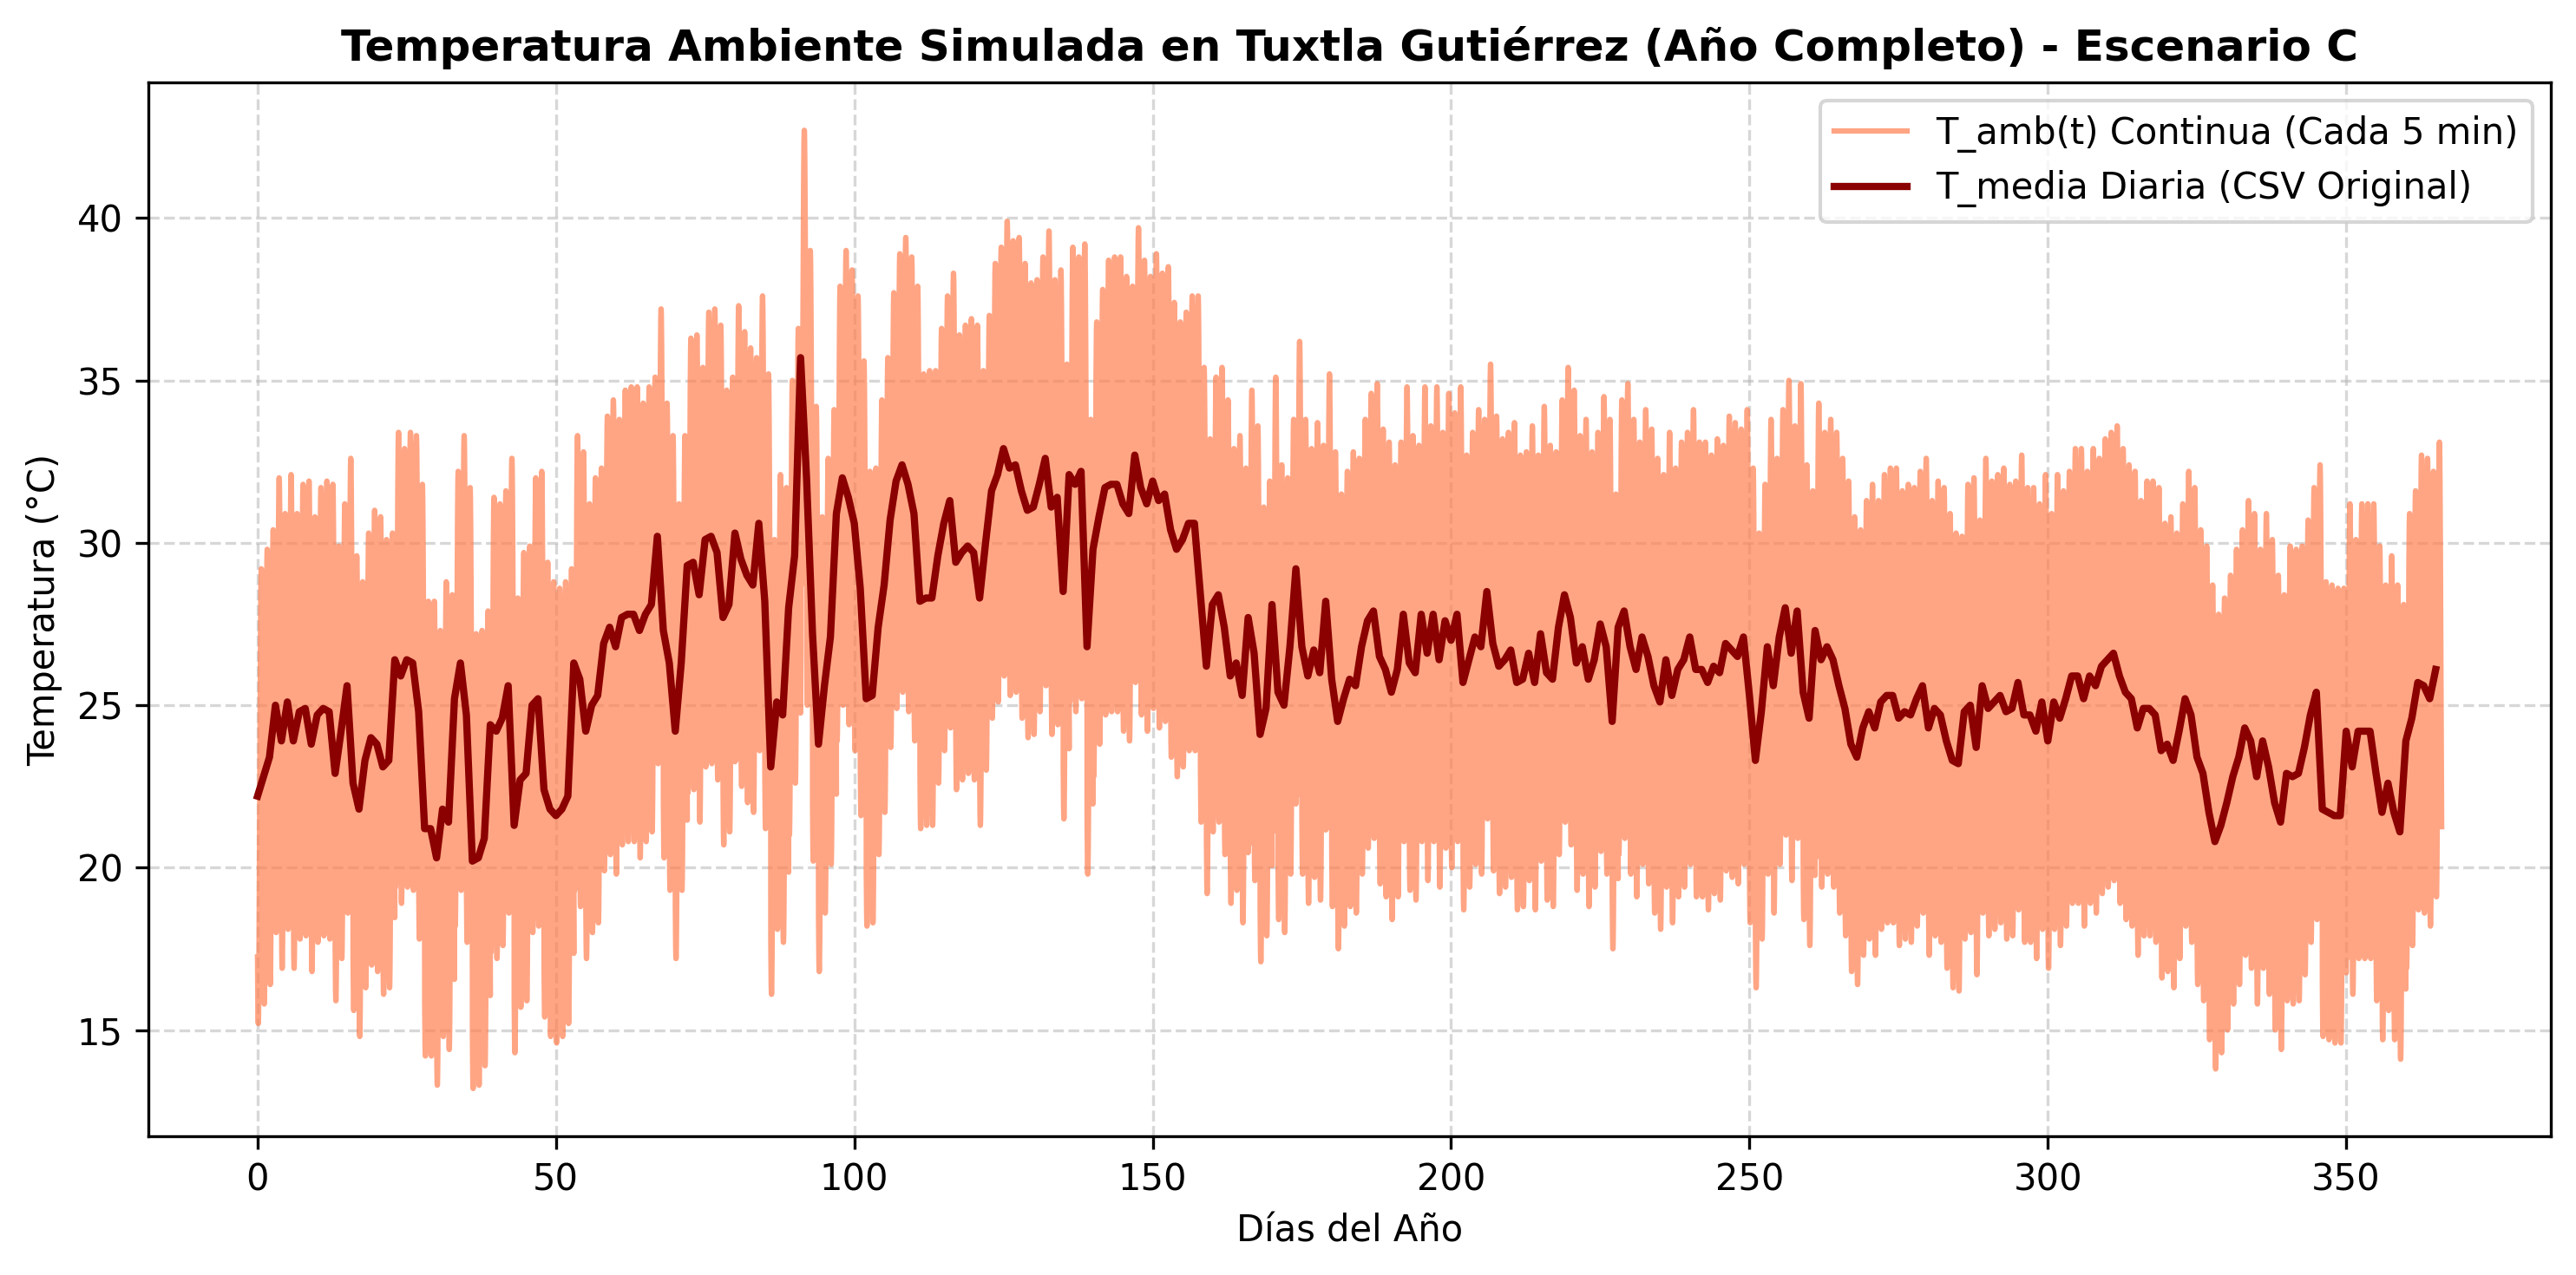

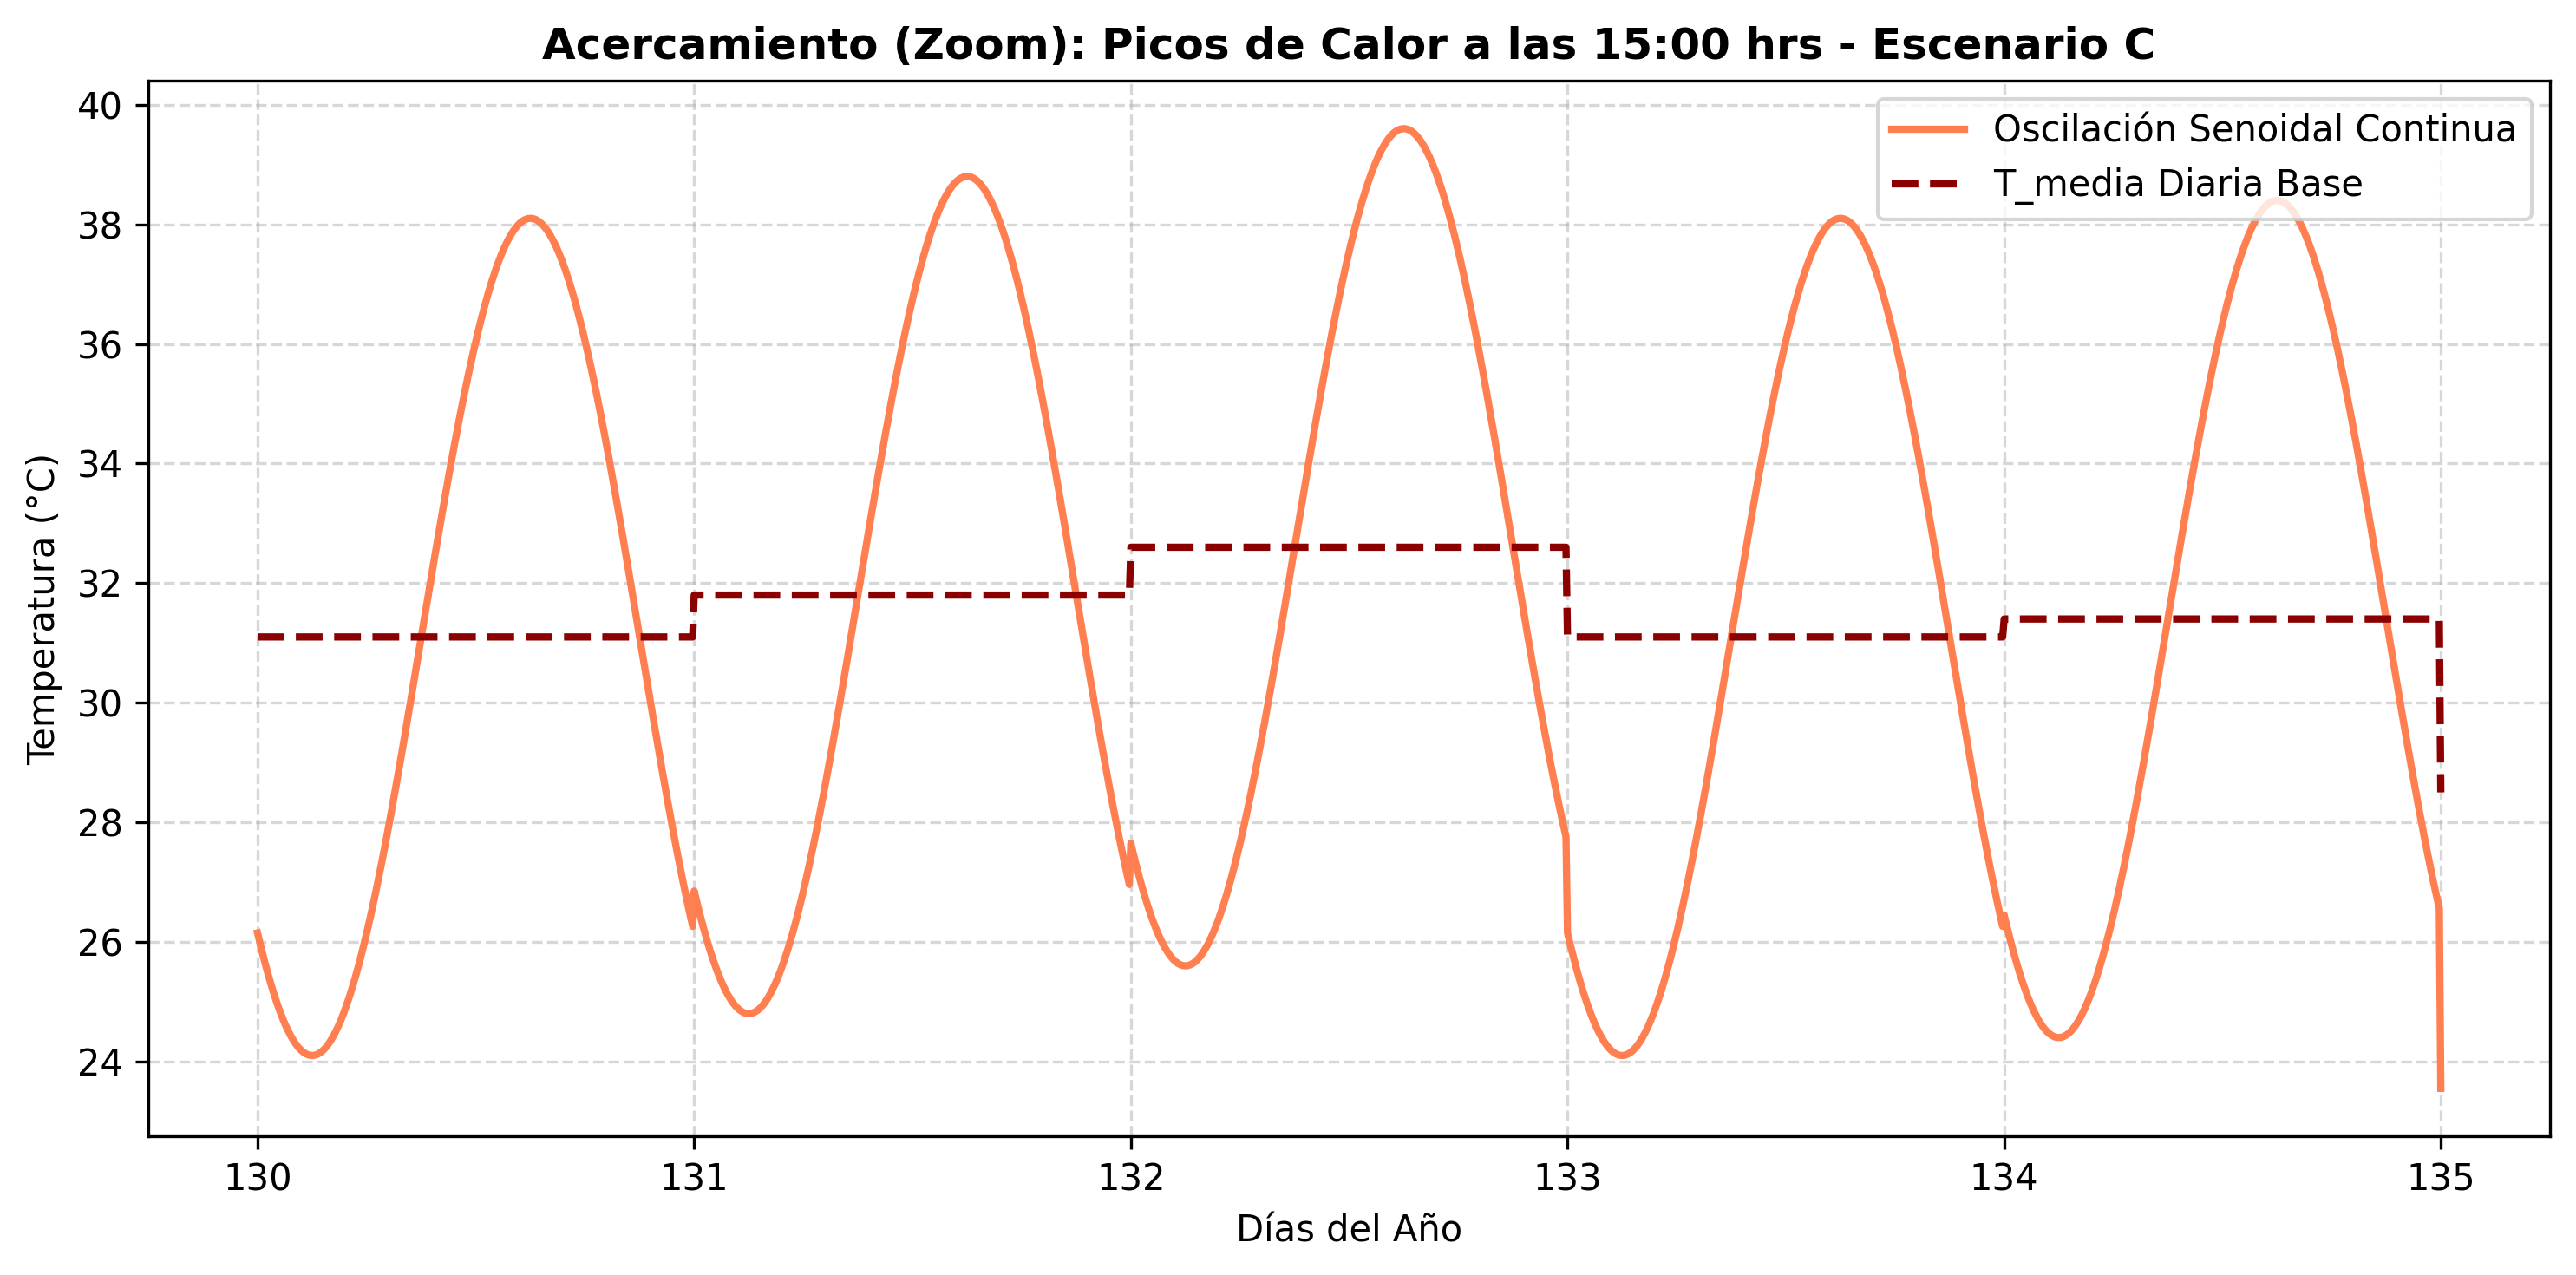

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. CARGA DE DATOS Y PREPARACIÓN DEL CALENDARIO LOGÍSTICO
ruta_csv = "/content/drive/MyDrive/CLIMA TUXLTA/CLIMA. TUXTLA/Clima de Tuxtla 2024.csv"
df = pd.read_csv(ruta_csv)

# Asegurar el formato de fecha y ordenar cronológicamente
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Definimos los días festivos oficiales de México en 2024
festivos_2024 = pd.to_datetime(['2024-01-01', '2024-02-05', '2024-03-18',
                                '2024-05-01', '2024-09-16', '2024-10-01',
                                '2024-11-18', '2024-12-25'])

# Creamos el arreglo booleano: True si es fin de semana (sábado=5, domingo=6) o festivo
df['es_fin_de_semana'] = df['date'].dt.dayofweek >= 5
df['es_festivo'] = df['date'].isin(festivos_2024)
df['es_inhabil'] = df['es_fin_de_semana'] | df['es_festivo']

# Extraemos la columna de temperatura e interpolamos los posibles valores nulos (NaNs)
df['tavg'] = df['tavg'].interpolate(method='linear')
T_diaria = df['tavg'].values               # Array de temperaturas diarias (366 días, 2024 fue bisiesto)
es_inhabil_diario = df['es_inhabil'].values # Array logístico de días inhábiles (366 días)

# 2. CREACIÓN DEL VECTOR DE TIEMPO (dt)
# Definimos el paso de integración en horas (5 minutos = 5/60 horas)
dt = 5 / 60.0
horas_totales = len(T_diaria) * 24
t_horas = np.arange(0, horas_totales, dt)

# 3. CONSTRUCCIÓN DE LA FUNCIÓN DETERMINISTA T_amb(t)
# Mapeamos la temperatura media a cada paso de 5 minutos
indices_dia = np.floor(t_horas / 24).astype(int)
indices_dia = np.clip(indices_dia, 0, len(T_diaria)-1) # Evitamos el desbordamiento de índice al final
T_media_expandida = T_diaria[indices_dia]

# Expandimos también el vector logístico para saber si cada paso de 5 min cae en día inhábil
es_inhabil_expandido = es_inhabil_diario[indices_dia]

# Sobreponemos la oscilación para capturar el estrés térmico a lo largo del día.
# Amplitud de 7°C, con el argumento del coseno ajustado (-15) para tener el pico a las 15:00 hrs.
amplitud_diurna = 7.0
T_amb_t = T_media_expandida + amplitud_diurna * np.cos(2 * np.pi * (t_horas - 15) / 24)

print(f"Pasos totales de simulación: {len(t_horas)} iteraciones de {dt*60:.0f} minutos.\n")

# 4. GRÁFICA DEL CLIMA
# --- GRÁFICA 1: Panorama Anual ---
plt.figure(figsize=(10, 5), dpi=300)
plt.plot(t_horas / 24, T_amb_t, color='coral', alpha=0.7, label='T_amb(t) Continua (Cada 5 min)')
plt.plot(np.arange(len(T_diaria)), T_diaria, color='darkred', lw=2, label='T_media Diaria (CSV Original)')
plt.title('Temperatura Ambiente Simulada en Tuxtla Gutiérrez (Año Completo) - Escenario C', fontweight='bold', fontsize=12)
plt.xlabel('Días del Año')
plt.ylabel('Temperatura (°C)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# Guardamos la imagen
plt.savefig('temp_anual_tuxtla_escenario_C.png', bbox_inches='tight', dpi=300)
plt.show()

# --- GRÁFICA 2: Zoom ---
dia_inicio_zoom = 130
dia_fin_zoom = 135
mascara_zoom = (t_horas >= dia_inicio_zoom * 24) & (t_horas <= dia_fin_zoom * 24)

plt.figure(figsize=(10, 5), dpi=300)
plt.plot(t_horas[mascara_zoom] / 24, T_amb_t[mascara_zoom], color='coral', lw=2, label='Oscilación Senoidal Continua')
plt.plot(t_horas[mascara_zoom] / 24, T_media_expandida[mascara_zoom], color='darkred', lw=2, linestyle='--', label='T_media Diaria Base')
plt.title('Acercamiento (Zoom): Picos de Calor a las 15:00 hrs - Escenario C', fontweight='bold', fontsize=12)
plt.xlabel('Días del Año')
plt.ylabel('Temperatura (°C)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# Guardamos la imagen
plt.savefig('temp_zoom_tuxtla_escenario_C.png', bbox_inches='tight', dpi=300)
plt.show()

## Celda 2: Calibración Física de la EDE y Reglas de la Clínica (Contingencia)

En esta sección definimos las constantes físicas del refrigerador y las reglas de máxima demanda para la clínica simulada.

1. **Parámetros Termodinámicos:** Asignamos los valores calibrados para el equipo Haier HBC-150 y fijamos el termostato en 5°C.
2. **Cinética de Degradación:** Definimos las constantes de la ecuación de Arrhenius para evaluar el daño biológico.
3. **Aperturas de Puerta (Estrés Operativo):** Además de la apertura de las 8:00 hrs y el resguardo vespertino, se activa una tasa de alta frecuencia matutina (09:00 a 14:00 hrs, $\lambda=0.4$) para simular los viajes de resurtido del personal ante la saturación clínica. El salto térmico se extrae de una Normal truncada y toda actividad cesa en días inhábiles.

In [ ]:
# 1. PARÁMETROS TERMODINÁMICOS (HAIER HBC-150)
kappa_on = 0.1154   # Velocidad de enfriamiento activo (compresor)
kappa_off = 0.00232 # Pérdida térmica inercial (aislamiento en apagón)
theta_set = 5.0     # Termostato ideal OMS (°C)

sigma_on = 0.4804   # Volatilidad con motor encendido
sigma_off = 0.048   # Volatilidad pasiva en apagón

T_0 = 5.0           # Temperatura inicial de arranque

# 2. PARÁMETROS DEL DAÑO TÉRMICO Y MAGNITUD DEL SALTO
Ea = 85000.0        # Energía de activación (J/mol)
R_gas = 8.314       # Constante de los gases
A_factor = 1.2e13   # Factor pre-exponencial

gamma_mu = 0.76     # Media del salto térmico (°C)
gamma_sigma = 0.20  # Desviación estándar del salto
gamma_min = 0.16    # Mínimo absoluto (Filtro termodinámico)

# 3. LÓGICA DE APERTURAS DE PUERTA (ESCENARIO C)
hora_dia = t_horas % 24

# Regla Matutina Fija (8:00 AM)
apertura_manana_fija = np.isclose(hora_dia, 8.0)
apertura_manana_fija[es_inhabil_expandido] = False

# Regla de Resurtido (09:00 a 14:00 hrs)
lambda_resurtido = np.zeros_like(t_horas)
mask_resurtido = (hora_dia >= 9) & (hora_dia < 14)
lambda_resurtido[mask_resurtido] = 0.4
lambda_resurtido[es_inhabil_expandido] = 0.0

# Regla Vespertina (15:00 a 17:00 hrs)
lambda_tarde = np.zeros_like(t_horas)
mask_tarde = (hora_dia >= 15) & (hora_dia < 17)
lambda_tarde[mask_tarde] = 0.5
lambda_tarde[es_inhabil_expandido] = 0.0

print("Parámetros termodinámicos y reglas de puerta en contingencia cargados (Escenario C).")

Parámetros termodinámicos y reglas de puerta en contingencia cargados (Escenario C).


## Celda 3: Parámetros del Suministro Eléctrico (CFE)

En esta celda modelamos el riesgo externo que sufre la red eléctrica. Como observamos en el análisis de datos, el clima afecta severamente la infraestructura, provocando que los apagones tengan una distribución anual asimétrica. Para simular esto en el centro de almacenamiento para vacunas, definimos dos funciones:

1. **Frecuencia de Apagones:** Programamos la función `tasa_cortes_cfe(t)`, que representa la intensidad $\lambda(t)$ de nuestro Proceso de Poisson No Homogéneo. Sumamos el riesgo base de fallas locales ($0.0667$) con dos campanas gaussianas que simulan los picos calibrados: el estrés por la ola de calor (centrado en el día 152, amplitud $0.2314$, varianza $4050$) y la temporada de tormentas (centrada en el día 244, amplitud $0.2048$, varianza $1800$).
2. **Duración de Apagones:** Programamos una función que devuelve los parámetros exactos $\mu$ y $\sigma$ de una distribución Log-Normal calibrada. El algoritmo evaluará en qué día del año se encuentra (Estabilidad, Calor o Lluvias) para asignar la duración correspondiente al apagón.

In [ ]:
# 1. MODELO DE ESTADO ELÉCTRICO S(t) - FRECUENCIA DE APAGONES

def tasa_cortes_cfe(dia_del_ano):
    """
    Intensidad diaria de fallas (Proceso de Poisson No Homogéneo).
    """
    # Riesgo base mínimo constante (mantenimiento o fallas locales)
    base = 0.0667

    # Pico 1: Temporada de calor extremo (Centro en el día 152, varianza 4050)
    k1 = 0.2314 * np.exp(-((dia_del_ano - 152)**2) / 4050)

    # Pico 2: Temporada de lluvias y tormentas (Centro en el día 244, varianza 1800)
    k2 = 0.2048 * np.exp(-((dia_del_ano - 244)**2) / 1800)

    return base + k1 + k2

# 2. DURACIÓN DEL APAGÓN - DISTRIBUCIÓN LOG-NORMAL

# Diccionario con los parámetros (mu, sigma) deducidos por el Método de Momentos.
parametros_duracion = {
    'Estabilidad': {'mu': 0.6766, 'sigma': 0.6202}, # Ene-Mar y Nov-Dic (Mantenimientos base)
    'Calor':       {'mu': 0.9627, 'sigma': 0.5106}, # Abr-Jul (Saturación térmica)
    'Lluvias':     {'mu': 0.4668, 'sigma': 0.3372}  # Ago-Oct (Tormentas rápidas)
}

def obtener_parametros_lognormal(dia_del_ano):
    """
    Revisa el día del año actual (1 a 366) y devuelve los parámetros de la
    distribución Log-Normal correspondiente a la temporada climática.
    """
    if 92 <= dia_del_ano <= 213:
        # Temporada: Abril - Julio (Estrés Térmico y Canícula)
        return parametros_duracion['Calor']['mu'], parametros_duracion['Calor']['sigma']

    elif 214 <= dia_del_ano <= 305:
        # Temporada: Agosto - Octubre (Lluvias y Huracanes)
        return parametros_duracion['Lluvias']['mu'], parametros_duracion['Lluvias']['sigma']

    else:
        # Temporada: Noviembre - Marzo (Estabilidad Invernal)
        return parametros_duracion['Estabilidad']['mu'], parametros_duracion['Estabilidad']['sigma']

print("Funciones y parámetros del suministro eléctrico (CFE) cargados (Escenario C).")

Funciones y parámetros del suministro eléctrico (CFE) cargados (Escenario C).


## Celda 4: Generación de Trayectorias de Red Eléctrica y Saltos (Contingencia)

En esta celda pre-calculamos de forma vectorizada los dos procesos estocásticos externos que perturbarán a nuestra Ecuación Diferencial Estocástica (EDE) en la simulación:

1. **Estado Eléctrico $S(t)$:** Recorremos todos los días del año. Para cada día, hacemos un muestreo de Poisson utilizando nuestra tasa de fallas de la CFE ($\lambda(t)$). Si ocurre un apagón, calculamos su duración utilizando la distribución Log-Normal calibrada a esa temporada climática y modificamos el vector $S(t)$ (cambiando su valor de 1 a 0 durante ese intervalo). Este vector equivale a la variable $\alpha(t)$ del modelo teórico.
2. **Proceso de Saltos (Aperturas):** Generamos el vector que indicará en qué momento ocurren las extracciones. Sumamos la apertura fija matutina, los viajes de resurtido (alta frecuencia) y el resguardo vespertino. Por cada evento registrado, calculamos la magnitud del ingreso de calor ($\gamma$) muestreando nuestra distribución Normal truncada. Finalmente, multiplicamos los eventos por el vector $S(t)$; esto garantiza que si no hay luz en el centro de almacenamiento para vacunas, el personal obedece la normativa de contingencia y el equipo permanece cerrado.

In [ ]:
np.random.seed(42) # Fijamos semilla para que la prueba base sea reproducible

# 1. GENERACIÓN DE APAGONES - ESTADO ELÉCTRICO S(t)
S_t = np.ones(len(t_horas))
dias_totales = int(np.ceil(t_horas[-1] / 24))

for dia in range(dias_totales):
    tasa_hoy = tasa_cortes_cfe(dia)
    num_cortes = np.random.poisson(tasa_hoy)

    for _ in range(num_cortes):
        hora_inicio = (dia * 24) + np.random.uniform(0, 24)
        mu_ln, sigma_ln = obtener_parametros_lognormal(dia)
        duracion_horas = np.random.lognormal(mu_ln, sigma_ln)

        idx_inicio = int(hora_inicio / dt)
        idx_fin = int((hora_inicio + duracion_horas) / dt)

        if idx_inicio < len(S_t):
            idx_fin = min(idx_fin, len(S_t))
            S_t[idx_inicio:idx_fin] = 0

transiciones = np.sum(np.diff(S_t) == -1)
print(f"Trayectoria eléctrica S(t) generada. Ocurrieron {transiciones} apagones en el año.")

# 2. GENERACIÓN DEL PROCESO DE SALTOS (Escenario C)
Saltos_Termicos_t = np.zeros(len(t_horas))

# A. Eventos estocásticos y deterministas
esperados_tarde = lambda_tarde * dt
esperados_resurtido = lambda_resurtido * dt

dN_t_tarde = np.random.poisson(esperados_tarde)
dN_t_resurtido = np.random.poisson(esperados_resurtido)
dN_t_manana = apertura_manana_fija.astype(int)

# Sumamos todos los eventos
dN_t_total = dN_t_tarde + dN_t_resurtido + dN_t_manana

# Regla normativa de contingencia: Si no hay luz (S_t == 0), las aperturas se cancelan
dN_t_total = dN_t_total * S_t

# Muestreo de la magnitud del salto térmico (Normal Truncada)
for i in range(len(t_horas)):
    if dN_t_total[i] > 0:
        eventos = int(dN_t_total[i])
        saltos = np.random.normal(gamma_mu, gamma_sigma, eventos)
        saltos = np.maximum(gamma_min, saltos) # Truncamiento inferior
        Saltos_Termicos_t[i] = np.sum(saltos)

aperturas_totales = np.sum(dN_t_total)
print(f"Vector de saltos generado. La puerta se abrió {aperturas_totales:.0f} veces en el año (Estrés Operativo).")

Trayectoria eléctrica S(t) generada. Ocurrieron 68 apagones en el año.
Vector de saltos generado. La puerta se abrió 995 veces en el año (Estrés Operativo).


## Celda 5: Resolución Numérica de la EDE y Dinámica Térmica (Contingencia)

En esta celda integramos paso a paso la Ecuación Diferencial Estocástica (EDE) para el escenario de estrés operativo. Hacemos lo siguiente:

1. **Integración Numérica (Euler-Maruyama):** Utilizamos este esquema porque en nuestro modelo de Ornstein-Uhlenbeck, el coeficiente de difusión (volatilidad $\sigma$) es constante para cada régimen y no depende de la temperatura. Dado que su derivada es cero, el término de corrección del método de Milstein se anula, reduciéndose exactamente al esquema de Euler-Maruyama.
2. **Métricas de Seguridad (Excursiones y Tiempos):** El algoritmo cuenta cuántos eventos (cruces de línea) superaron el límite de 8°C o cayeron bajo 2°C. Además, convierte las iteraciones totales a horas físicas y porcentajes anuales para cuantificar exactamente el tiempo que el centro de almacenamiento para vacunas estuvo fuera de la norma.
3. **Visualización de la Dinámica Térmica:** Generamos el panorama térmico anual y un acercamiento completo a todo el mes de enero para observar la saturación térmica generada por los viajes de resurtido.

Integrando la SDE con el esquema de Euler-Maruyama...
Integración completada exitosamente.

-> EXCURSIONES SOBRE 8°C:
   Eventos individuales: 435
   Tiempo acumulado: 475.00 horas (5.41% del año)
   Primer registro crítico en el Día 4.65

-> EXCURSIONES BAJO 2°C:
   Eventos individuales: 0
   Tiempo acumulado: 0.00 horas (0.00% del año)

=> TIEMPO TOTAL FUERA DE RANGO: 475.00 horas (5.41% del año)



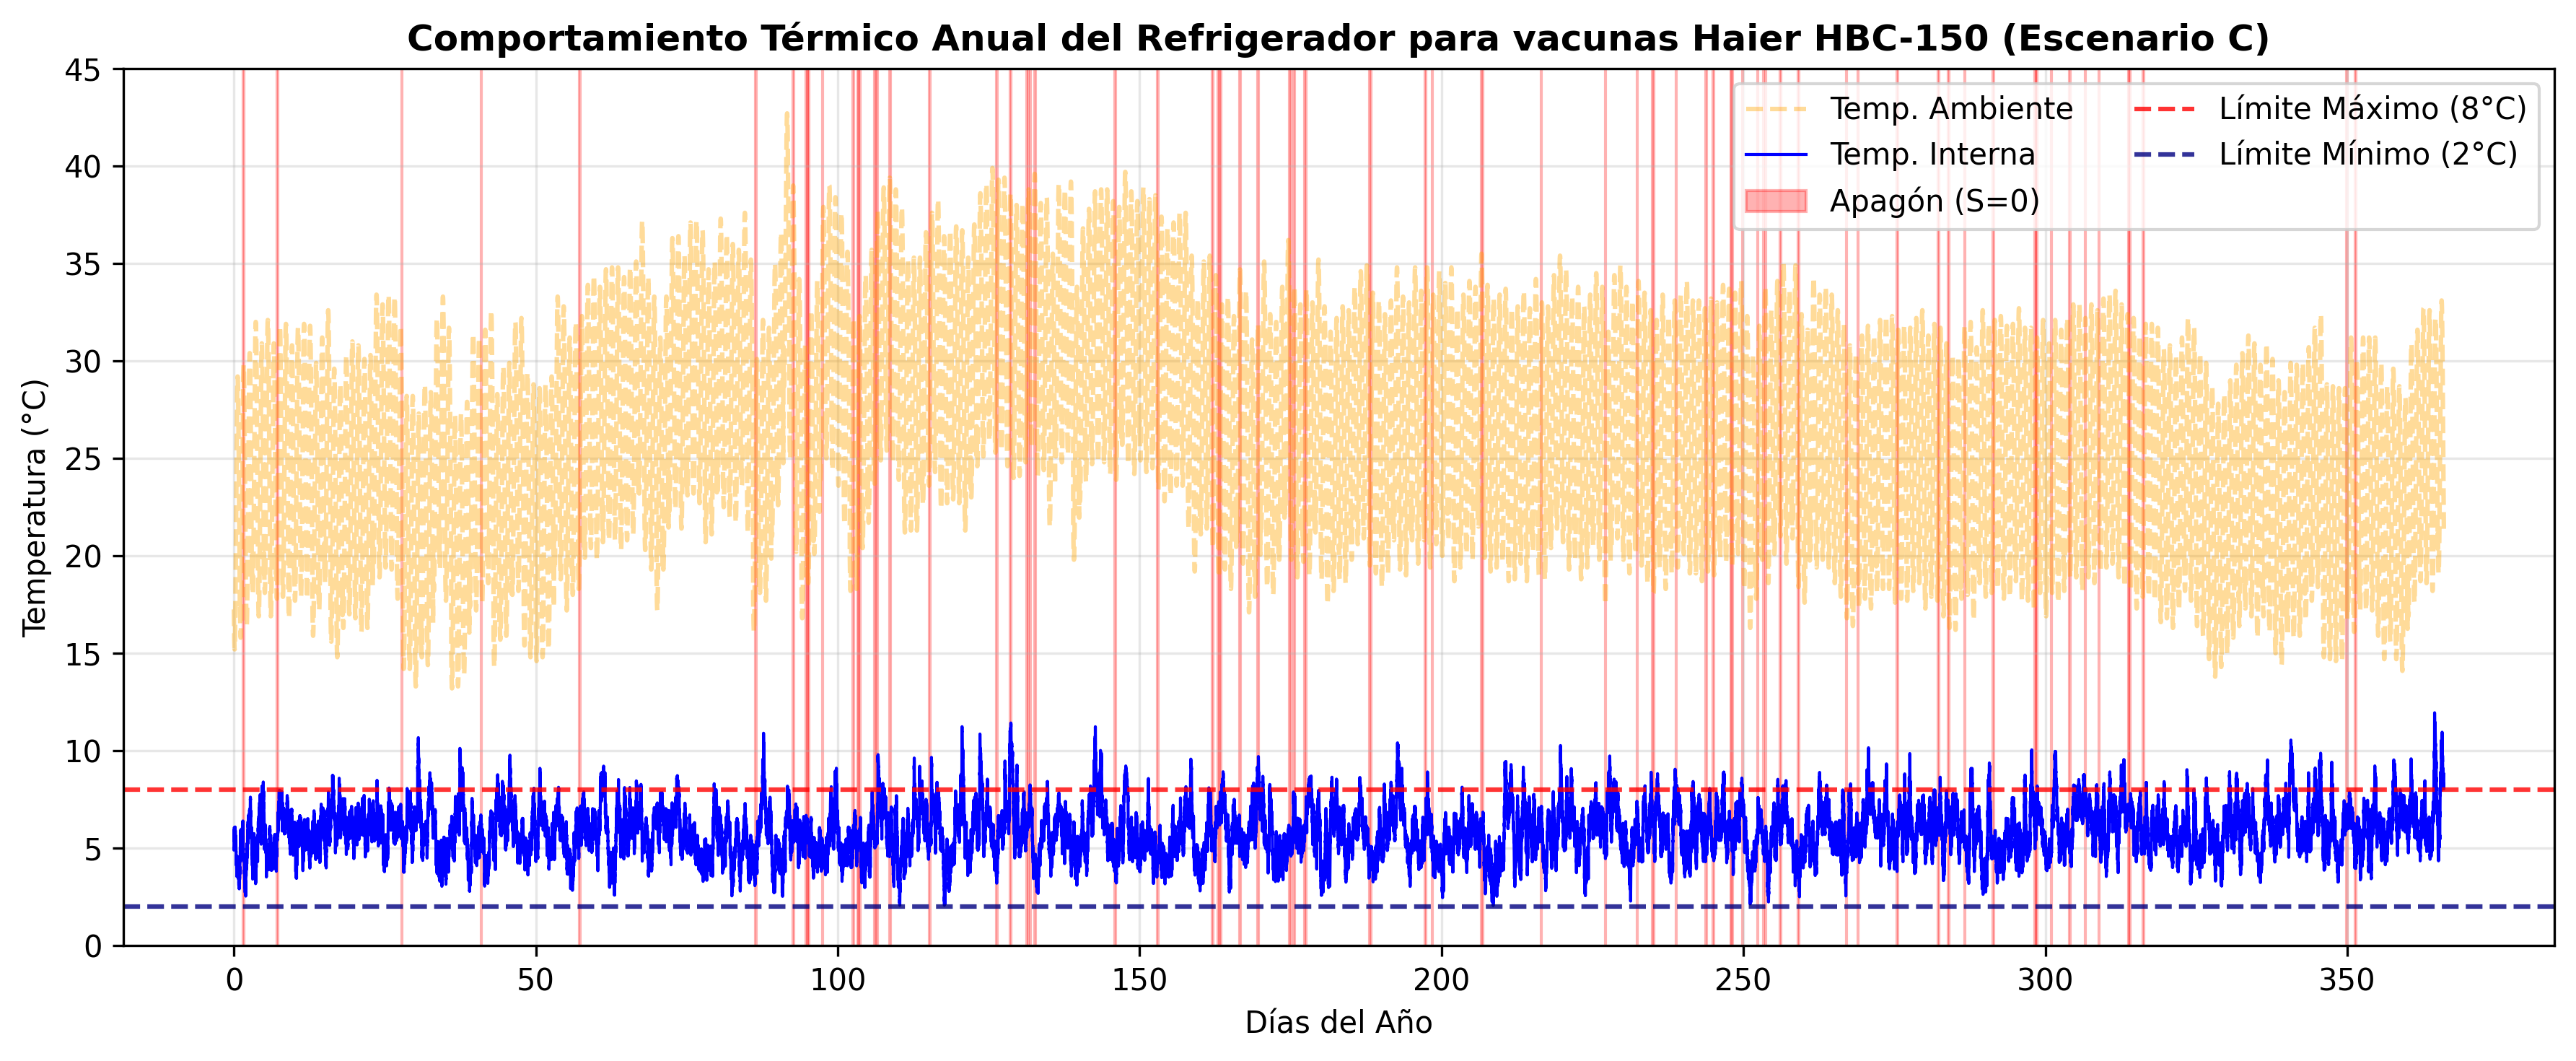

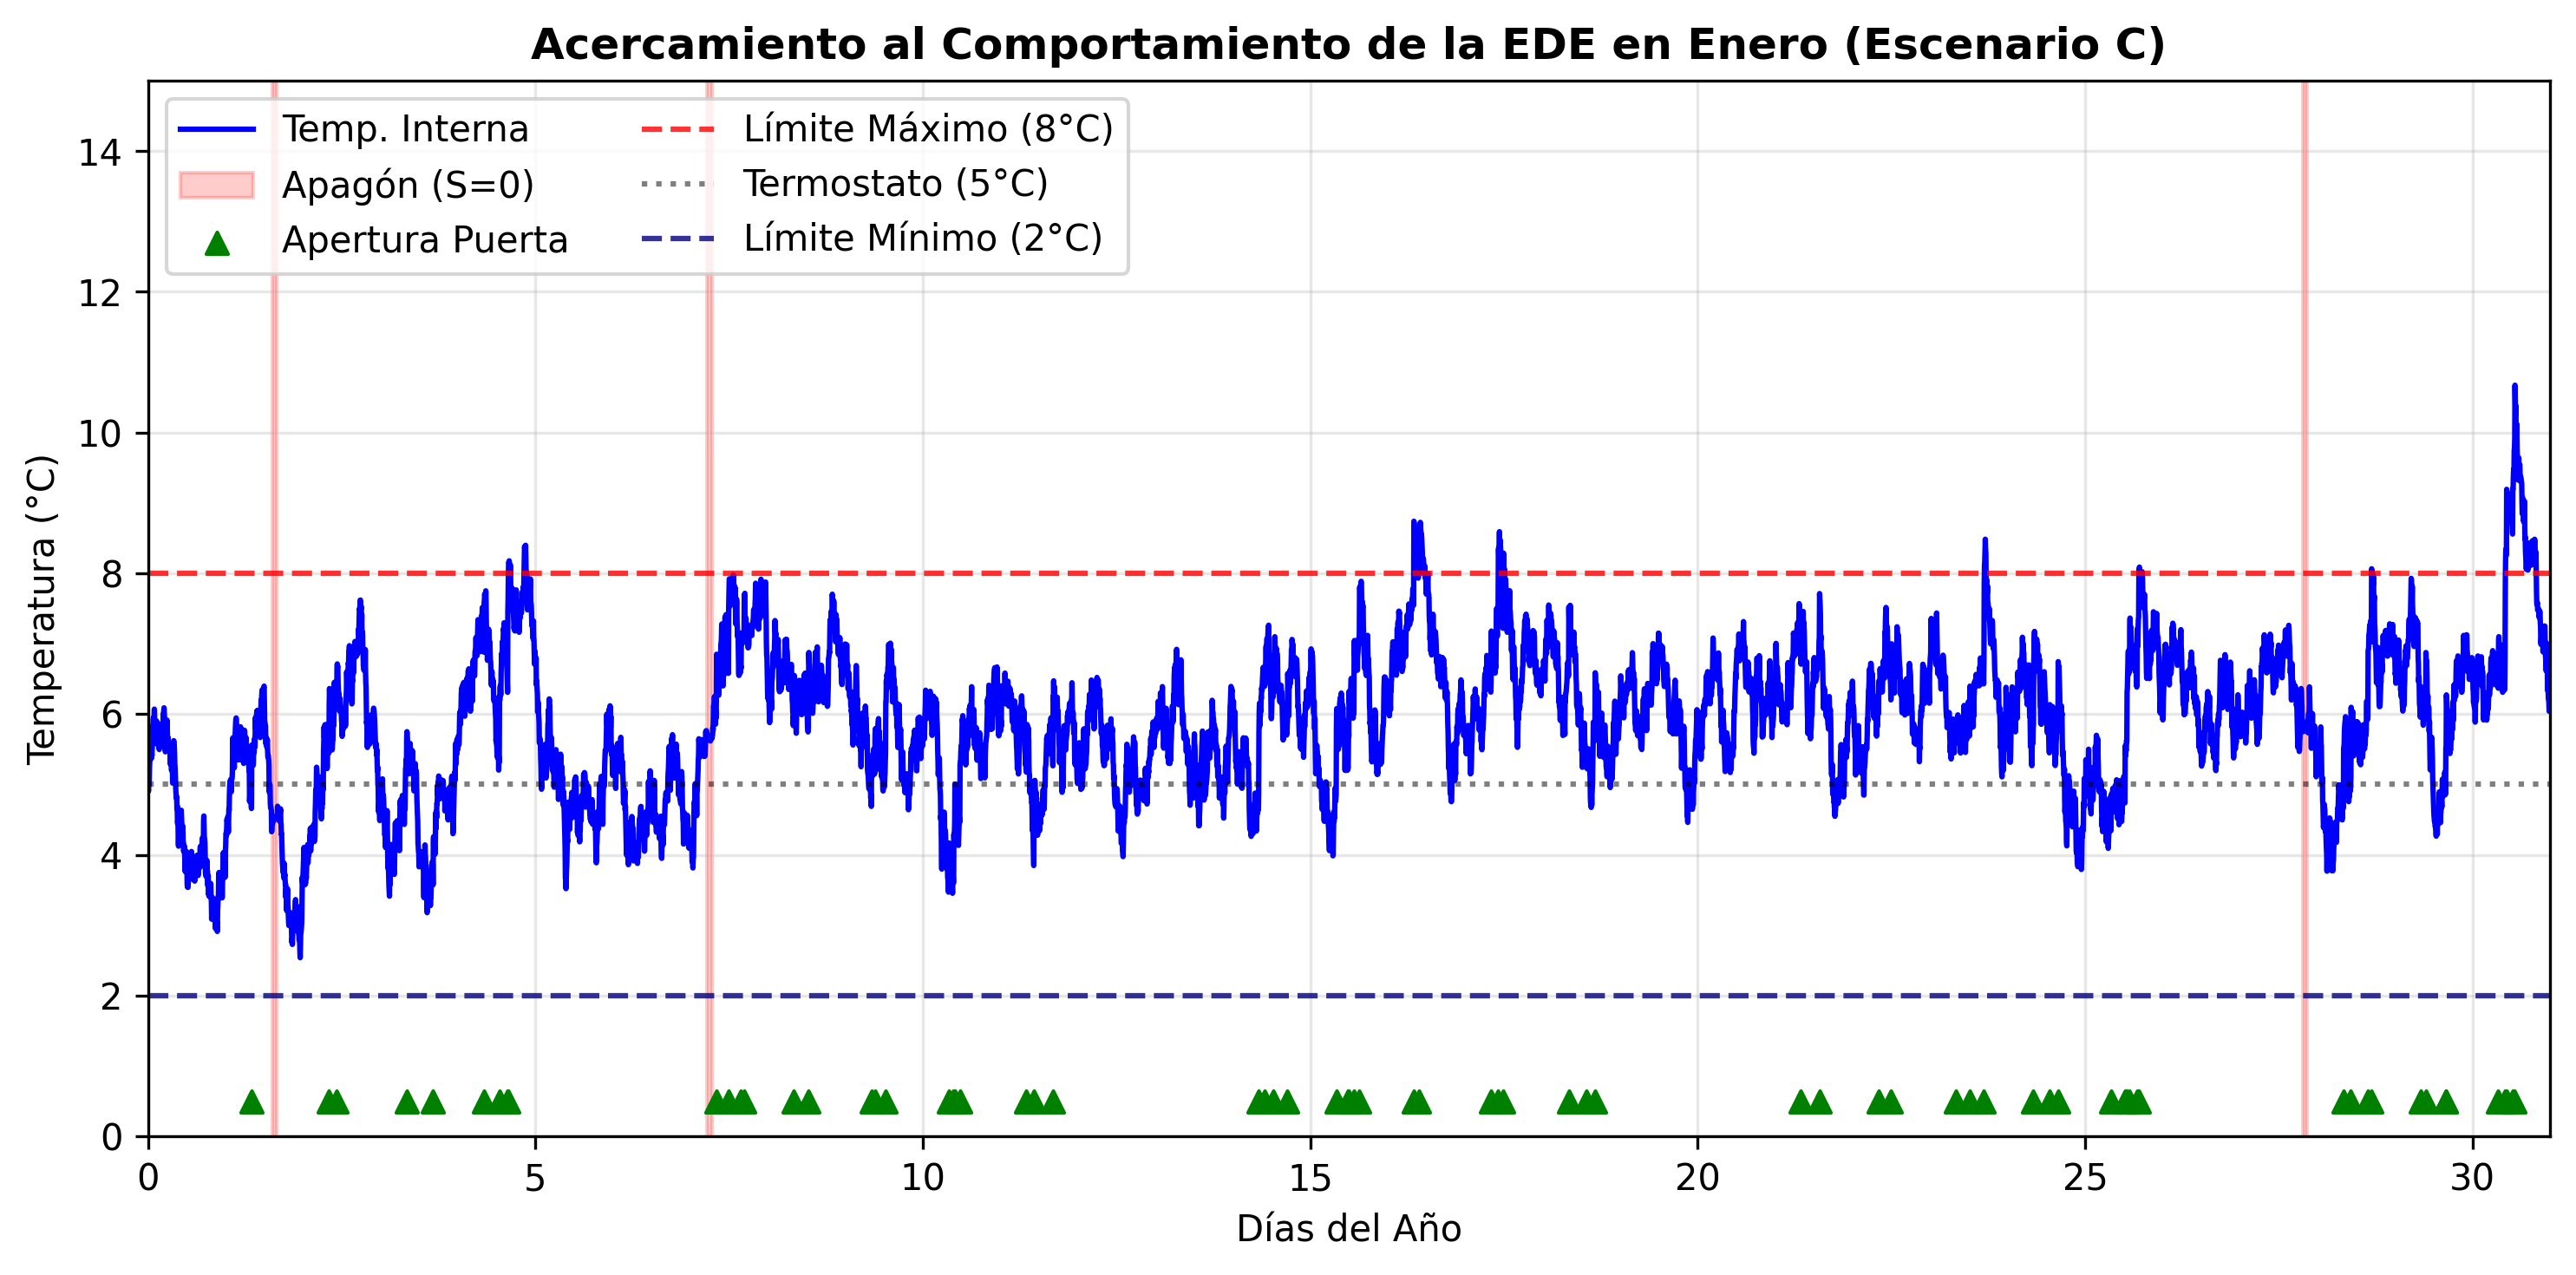

In [ ]:
# 1. PREPARACIÓN DE VECTORES PARA LA INTEGRACIÓN
np.random.seed(13) # Fijamos semilla para que la trayectoria sea comparable entre escenarios
X_t = np.zeros(len(t_horas))
X_t[0] = T_0                # Iniciamos en el termostato (5°C)

print("Integrando la SDE con el esquema de Euler-Maruyama...")

# 2. BUCLE DE INTEGRACIÓN NUMÉRICA
for i in range(1, len(t_horas)):
    # Incremento del Movimiento Browniano
    dW = np.sqrt(dt) * np.random.randn()

    # Evaluamos el régimen eléctrico (Regime-Switching)
    if S_t[i-1] == 1:
        # Régimen 1: Compresor operando
        drift = kappa_on * (theta_set - X_t[i-1]) * dt
        difusion = sigma_on * dW
        salto = Saltos_Termicos_t[i-1]
    else:
        # Régimen 2: Apagón
        drift = kappa_off * (T_amb_t[i-1] - X_t[i-1]) * dt
        difusion = sigma_off * dW
        salto = 0 # El centro de almacenamiento para vacunas no abre sus puertas sin luz

    # Euler-Maruyama
    X_t[i] = X_t[i-1] + drift + difusion + salto

# 3. MÉTRICAS DE EVENTOS Y TIEMPOS NORMATIVOS
sobrepasos_8 = X_t > 8.0
sobrepasos_2 = X_t < 2.0

# Contamos eventos lógicos (cruces) y el total de iteraciones (tiempo)
eventos_8 = np.sum((sobrepasos_8[1:] & ~sobrepasos_8[:-1]))
eventos_2 = np.sum((sobrepasos_2[1:] & ~sobrepasos_2[:-1]))

horas_8 = np.sum(sobrepasos_8) * dt
horas_2 = np.sum(sobrepasos_2) * dt
horas_totales_falla = horas_8 + horas_2
horas_ano = 366 * 24

print("Integración completada exitosamente.\n")
print(f"-> EXCURSIONES SOBRE 8°C:")
print(f"   Eventos individuales: {eventos_8}")
print(f"   Tiempo acumulado: {horas_8:.2f} horas ({horas_8/horas_ano*100:.2f}% del año)")
if eventos_8 > 0:
    print(f"   Primer registro crítico en el Día {t_horas[sobrepasos_8][0]/24:.2f}")

print(f"\n-> EXCURSIONES BAJO 2°C:")
print(f"   Eventos individuales: {eventos_2}")
print(f"   Tiempo acumulado: {horas_2:.2f} horas ({horas_2/horas_ano*100:.2f}% del año)")
if eventos_2 > 0:
    print(f"   Primer registro crítico en el Día {t_horas[sobrepasos_2][0]/24:.2f}")

print(f"\n=> TIEMPO TOTAL FUERA DE RANGO: {horas_totales_falla:.2f} horas ({horas_totales_falla/horas_ano*100:.2f}% del año)\n")

# 4. GRÁFICAS DE LA DINÁMICA TÉRMICA

# --- GRÁFICA 1: Panorama Anual ---
plt.figure(figsize=(12, 5), dpi=300)
plt.plot(t_horas/24, T_amb_t, color='orange', alpha=0.4, linestyle='--', label='Temp. Ambiente')
plt.plot(t_horas/24, X_t, color='blue', linewidth=1.0, label='Temp. Interna')
plt.fill_between(t_horas/24, 0, 45, where=(S_t==0), color='red', alpha=0.3, label='Apagón (S=0)')

plt.axhline(y=8.0, color='red', linestyle='--', alpha=0.8, label='Límite Máximo (8°C)')
plt.axhline(y=2.0, color='navy', linestyle='--', alpha=0.8, label='Límite Mínimo (2°C)')

plt.ylim(0, 45)
plt.ylabel('Temperatura (°C)')
plt.xlabel('Días del Año')
plt.title('Comportamiento Térmico Anual del Refrigerador para vacunas Haier HBC-150 (Escenario C)', fontweight='bold')
plt.legend(loc='upper right', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sde_anual_escenario_C.png', bbox_inches='tight', dpi=300)
plt.show()

# --- GRÁFICA 2: Zoom a Enero (31 días) ---
idx_start = 0
idx_end = int(31 * 24 / dt)

plt.figure(figsize=(10, 5), dpi=300)
plt.plot(t_horas[idx_start:idx_end]/24, X_t[idx_start:idx_end], color='blue', linewidth=1.5, label='Temp. Interna')

apagones_zoom = S_t[idx_start:idx_end]
plt.fill_between(t_horas[idx_start:idx_end]/24, 0, 15, where=(apagones_zoom==0), color='red', alpha=0.2, label='Apagón (S=0)')

aperturas_idx = np.where(dN_t_total[idx_start:idx_end] > 0)[0]
if len(aperturas_idx) > 0:
    plt.scatter(t_horas[idx_start + aperturas_idx]/24, np.zeros(len(aperturas_idx)) + 0.5, color='green', marker='^', zorder=5, label='Apertura Puerta')

plt.axhline(y=8.0, color='red', linestyle='--', alpha=0.8, label='Límite Máximo (8°C)')
plt.axhline(y=5.0, color='black', linestyle=':', alpha=0.5, label='Termostato (5°C)')
plt.axhline(y=2.0, color='navy', linestyle='--', alpha=0.8, label='Límite Mínimo (2°C)')

plt.ylim(0, 15)
plt.xlim(0, 31)
plt.ylabel('Temperatura (°C)')
plt.xlabel('Días del Año')
plt.title('Acercamiento al Comportamiento de la EDE en Enero (Escenario C)', fontweight='bold')
plt.legend(loc='upper left', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sde_zoom_escenario_C.png', bbox_inches='tight', dpi=300)
plt.show()

## Celda 6: Análisis de Impacto Logístico (Inventario vs. Mermas)

En esta sección traducimos el daño térmico en pérdidas absolutas de inventario físico. Para ello creamos dos modelos:

1. **Modelo Logístico Acoplado (Inventario $I_t$):** Simulamos el consumo bajo contingencia. La demanda **se acopla dinámicamente a las aperturas** de resurtido. En el minuto exacto donde ocurre un viaje por sobresaturación, se descuenta un bloque adicional de vacunas. Si este estrés agota el inventario (20%), simulamos la llegada de un nuevo camión.
2. **Cálculo de Dosis Perdidas:** La temperatura simulada por la EDE corresponde a la temperatura interna del refri. Sin embargo, el biológico líquido dentro de los frascos posee inercia térmica, tardando unos 30 minutos en calentarse. Por ello, la Ecuación de Arrhenius solo comienza a destruir el inventario si la temperatura permanece por encima de los 8°C de manera sostenida por más de 30 minutos (6 iteraciones continuas).
3. **Visualización:** Generamos una gráfica de doble eje para observar el consumo acelerado y cómo la destrucción se dispara cuando la saturación logística coincide temporalmente con un apagón sostenido.

Total de vacunas que ingresaron al centro de almacenamiento en el año: 77843 dosis.
Total de vacunas destruidas: 2395 dosis.
Porcentaje de pérdida: 3.08%



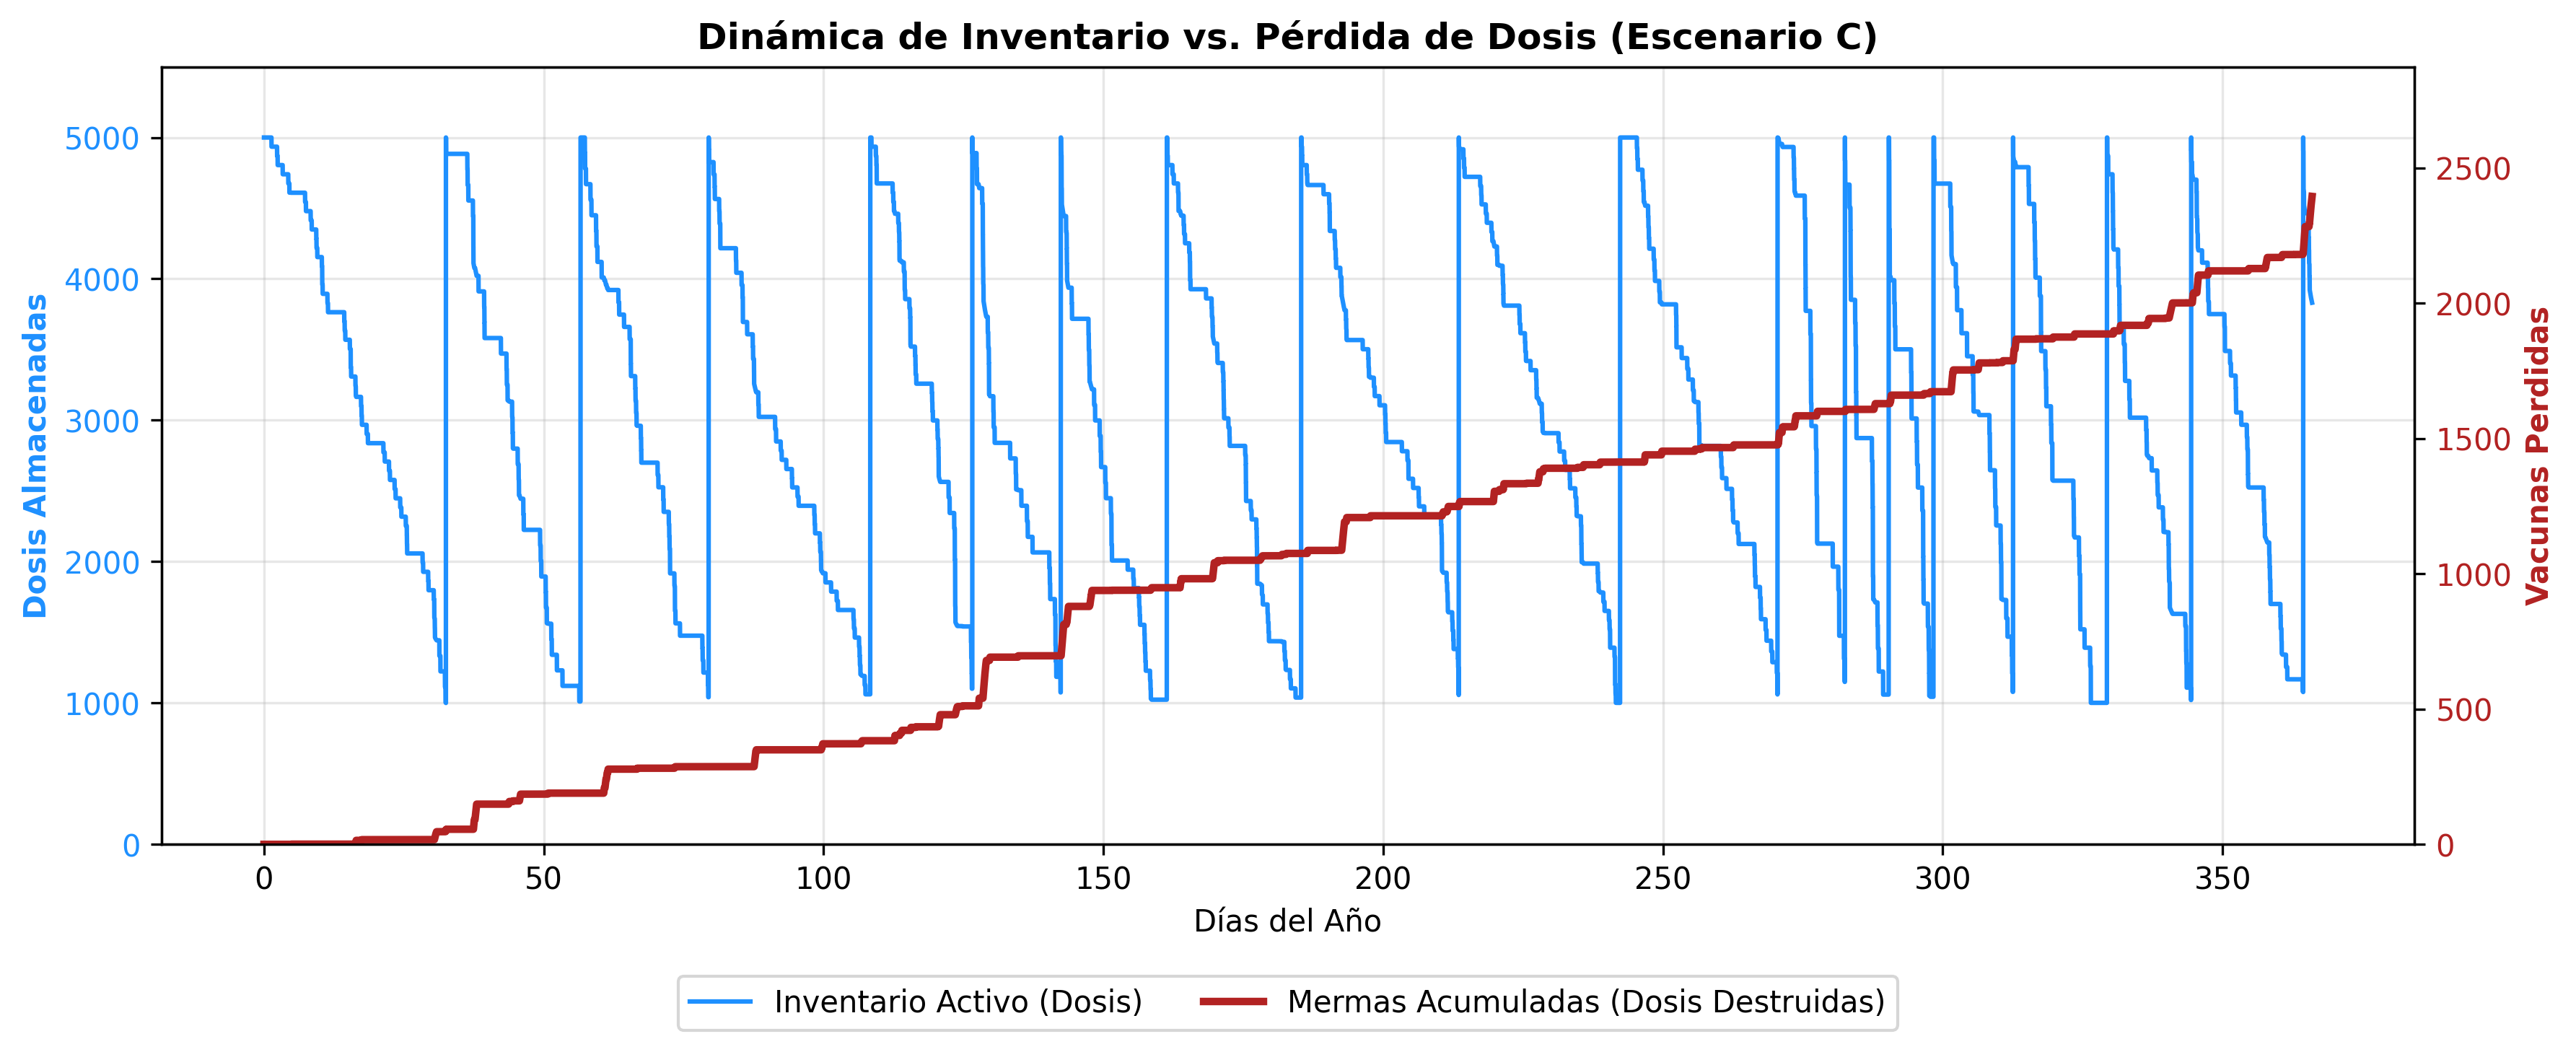

In [ ]:
# 1. PARÁMETROS DEL INVENTARIO LOGÍSTICO
capacidad_maxima = 5000.0  # Dosis máximas en el volumen útil del Haier HBC-150
punto_reorden = 1000.0     # Stock de seguridad (20%)

# Consumo diario base por mes (Ene a Dic)
consumo_diario_mes = [65, 110, 87, 65, 110, 65, 65, 65, 76, 163, 130, 87]

I_t = np.zeros(len(t_horas))
dosis_perdidas_dt = np.zeros(len(t_horas))

I_t[0] = capacidad_maxima
total_dosis_ingresadas = capacidad_maxima

# 2. BUCLE DINÁMICO: CONSUMO + MERMAS + REABASTECIMIENTO
tiempo_sobre_8 = 0  # Contador para la inercia térmica del frasco
tolerancia_pasos = 6 # 30 minutos (6 pasos de 5 min) de resistencia física

for i in range(1, len(t_horas)):
    inventario_actual = I_t[i-1]

    dia = int(t_horas[i] // 24)
    mes_actual = min(int((dia % 366) / 30.5), 11)

    # A. Consumo normativo (Exactamente en la apertura de las 8:00 AM)
    if apertura_manana_fija[i]:
        inventario_actual -= consumo_diario_mes[mes_actual]

    # Acoplamiento Estocástico: Extracciones por contingencia (Resurtido)
    if dN_t_resurtido[i] > 0:
        extraccion_extra = consumo_diario_mes[mes_actual] * int(dN_t_resurtido[i])
        inventario_actual -= extraccion_extra

    # B. Daño Térmico con Inercia del Frasco
    if X_t[i] > 8.0:
        tiempo_sobre_8 += 1
        # Solo empieza a hacer daño si el calor lleva más de 30 minutos sostenidos
        if tiempo_sobre_8 > tolerancia_pasos:
            T_kelvin = X_t[i] + 273.15
            k_t = A_factor * np.exp(-Ea / (R_gas * T_kelvin))
            fraccion_perdida = 1 - np.exp(-k_t * dt)
            merma_instante = inventario_actual * fraccion_perdida
        else:
            merma_instante = 0.0
    else:
        tiempo_sobre_8 = 0 # El equipo se enfrió, el contador se reinicia
        merma_instante = 0.0

    dosis_perdidas_dt[i] = merma_instante
    inventario_actual -= merma_instante

    # C. Reabastecimiento automático
    if inventario_actual <= punto_reorden:
        dosis_a_pedir = capacidad_maxima - inventario_actual
        total_dosis_ingresadas += dosis_a_pedir
        inventario_actual = capacidad_maxima

    I_t[i] = inventario_actual

# 3. RESULTADOS NUMÉRICOS
merma_acumulada_t = np.cumsum(dosis_perdidas_dt)
porcentaje_perdida = (merma_acumulada_t[-1] / total_dosis_ingresadas) * 100

print(f"Total de vacunas que ingresaron al centro de almacenamiento en el año: {total_dosis_ingresadas:.0f} dosis.")
print(f"Total de vacunas destruidas: {merma_acumulada_t[-1]:.0f} dosis.")
print(f"Porcentaje de pérdida: {porcentaje_perdida:.2f}%\n")

# 4. VISUALIZACIÓN LOGÍSTICA
plt.figure(figsize=(12, 5), dpi=300)

ax1 = plt.gca()
ax1.plot(t_horas/24, I_t, label='Inventario Activo (Dosis)', color='dodgerblue', linewidth=1.5)
ax1.set_xlabel('Días del Año')
ax1.set_ylabel('Dosis Almacenadas', color='dodgerblue', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='dodgerblue')
ax1.set_ylim(0, capacidad_maxima * 1.1)

ax2 = ax1.twinx()
ax2.plot(t_horas/24, merma_acumulada_t, label='Mermas Acumuladas (Dosis Destruidas)', color='firebrick', linewidth=2.5)
ax2.set_ylabel('Vacunas Perdidas', color='firebrick', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='firebrick')

max_merma_plot = np.max(merma_acumulada_t)
if max_merma_plot > 0:
    ax2.set_ylim(0, max_merma_plot * 1.2)
else:
    ax2.set_ylim(0, 10)

plt.title('Dinámica de Inventario vs. Pérdida de Dosis (Escenario C)', fontweight='bold', fontsize=12)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('inventario_vs_mermas_escenario_C.png', bbox_inches='tight', dpi=300)
plt.show()

## Celda 7: Simulación de Montecarlo

En esta sección consolidamos las dinámicas (térmica, eléctrica y logística) dentro de la función `simular_un_ano()`. El objetivo es generar una trayectoria completa en cuestión de segundos.

Para no depender de un solo escenario, aplicaremos el algoritmo de **Montecarlo con 5,000 simulaciones**. En cada iteración, el algoritmo extraerá y almacenará una amplia gama de métricas estadísticas sin conservar los arreglos gigantes de memoria (para evitar el desbordamiento de la RAM):
*   **Termodinámica:** Horas acumuladas y conteo de excursiones fuera de rango ($>8^\circ\text{C}$, $<2^\circ\text{C}$, y el riesgo crítico de congelación $<0^\circ\text{C}$).
*   **Logística y Riesgo:** El día exacto en que ocurrió la primera falla, el total de dosis destruidas, el porcentaje anual de pérdida y la merma estratificada por mes (para evaluar la estacionalidad del riesgo acoplado).

In [ ]:
import time

# 1. FUNCIÓN PRINCIPAL DE SIMULACIÓN ANUAL
def simular_un_ano(semilla, guardar_vectores=False):
    np.random.seed(semilla)

    S_t = np.ones(len(t_horas))
    I_t = np.zeros(len(t_horas))
    dosis_perdidas_dt = np.zeros(len(t_horas))
    merma_por_mes = np.zeros(12)

    inventario_actual = capacidad_maxima
    total_dosis_ingresadas = capacidad_maxima
    dias_totales = int(np.ceil(t_horas[-1] / 24))

    # A. Generación de Apagones
    for dia in range(dias_totales):
        num_cortes = np.random.poisson(tasa_cortes_cfe(dia))
        for _ in range(num_cortes):
            hora_inicio = (dia * 24) + np.random.uniform(0, 24)
            mu_ln, sigma_ln = obtener_parametros_lognormal(dia)
            duracion_horas = np.random.lognormal(mu_ln, sigma_ln)

            idx_inicio = int(hora_inicio / dt)
            idx_fin = int((hora_inicio + duracion_horas) / dt)
            if idx_inicio < len(S_t):
                idx_fin = min(idx_fin, len(S_t))
                S_t[idx_inicio:idx_fin] = 0

    # B. Generación de Aperturas y Saltos Térmicos (Contingencia)
    dN_t_tarde = np.random.poisson(lambda_tarde * dt)
    dN_t_resurtido = np.random.poisson(lambda_resurtido * dt)

    dN_t_total = (dN_t_tarde + dN_t_resurtido + apertura_manana_fija.astype(int)) * S_t

    Saltos_Termicos_t = np.zeros(len(t_horas))
    indices_aperturas = np.where(dN_t_total > 0)[0]
    for idx in indices_aperturas:
        ev = int(dN_t_total[idx])
        s = np.random.normal(gamma_mu, gamma_sigma, ev)
        Saltos_Termicos_t[idx] = np.sum(np.maximum(gamma_min, s))

    # C. Integración SDE
    X_t = np.zeros(len(t_horas))
    X_t[0] = T_0
    dW_vec = np.sqrt(dt) * np.random.randn(len(t_horas))

    tiempo_sobre_8 = 0
    tolerancia_pasos = 6

    for i in range(1, len(t_horas)):
        if S_t[i-1] == 1:
            drift = kappa_on * (theta_set - X_t[i-1]) * dt
            difusion = sigma_on * dW_vec[i]
            salto = Saltos_Termicos_t[i-1]
        else:
            drift = kappa_off * (T_amb_t[i-1] - X_t[i-1]) * dt
            difusion = sigma_off * dW_vec[i]
            salto = 0

        X_t[i] = X_t[i-1] + drift + difusion + salto

        dia_actual = int(t_horas[i] // 24)
        mes_actual = min(int((dia_actual % 366) / 30.5), 11)

        # D. Lógica de Consumo Acoplado (Demanda + Resurtidos)
        if apertura_manana_fija[i]:
            inventario_actual -= consumo_diario_mes[mes_actual]

        if dN_t_resurtido[i] > 0:
            extraccion_extra = consumo_diario_mes[mes_actual] * int(dN_t_resurtido[i])
            inventario_actual -= extraccion_extra

        # E. Lógica de Merma y Arrhenius
        if X_t[i] > 8.0:
            tiempo_sobre_8 += 1
            if tiempo_sobre_8 > tolerancia_pasos:
                T_kelvin = X_t[i] + 273.15
                k_t = A_factor * np.exp(-Ea / (R_gas * T_kelvin))
                fraccion_perdida = 1 - np.exp(-k_t * dt)
                merma_instante = inventario_actual * fraccion_perdida
            else:
                merma_instante = 0.0
        else:
            tiempo_sobre_8 = 0
            merma_instante = 0.0

        dosis_perdidas_dt[i] = merma_instante
        inventario_actual -= merma_instante
        merma_por_mes[mes_actual] += merma_instante

        # F. Reabastecimiento
        if inventario_actual <= punto_reorden:
            total_dosis_ingresadas += (capacidad_maxima - inventario_actual)
            inventario_actual = capacidad_maxima

        I_t[i] = inventario_actual

    # G. Extracción de Métricas Estadísticas
    sobrepasos_8 = X_t > 8.0
    sobrepasos_2 = X_t < 2.0
    sobrepasos_0 = X_t < 0.0

    horas_8 = np.sum(sobrepasos_8) * dt
    horas_2 = np.sum(sobrepasos_2) * dt
    horas_0 = np.sum(sobrepasos_0) * dt
    horas_ano = len(t_horas) * dt

    resultado = {
        'merma_anual': np.sum(dosis_perdidas_dt),
        'porcentaje_perdida': (np.sum(dosis_perdidas_dt) / total_dosis_ingresadas) * 100,
        'dosis_totales_ingresadas': total_dosis_ingresadas,
        'total_apagones': np.sum(np.diff(S_t) == -1),
        'total_aperturas': np.sum(dN_t_total),
        'merma_por_mes': merma_por_mes,
        'eventos_8': np.sum((sobrepasos_8[1:] & ~sobrepasos_8[:-1])),
        'eventos_2': np.sum((sobrepasos_2[1:] & ~sobrepasos_2[:-1])),
        'eventos_0': np.sum((sobrepasos_0[1:] & ~sobrepasos_0[:-1])),
        'horas_8': horas_8,
        'horas_2': horas_2,
        'horas_0': horas_0,
        'porcentaje_horas_8': (horas_8 / horas_ano) * 100,
        'porcentaje_horas_2': (horas_2 / horas_ano) * 100,
        'porcentaje_horas_0': (horas_0 / horas_ano) * 100,
        'primer_dia_8': (np.where(sobrepasos_8)[0][0] * dt)/24 if np.any(sobrepasos_8) else np.nan,
        'primer_dia_2': (np.where(sobrepasos_2)[0][0] * dt)/24 if np.any(sobrepasos_2) else np.nan,
        'primer_dia_0': (np.where(sobrepasos_0)[0][0] * dt)/24 if np.any(sobrepasos_0) else np.nan
    }

    if guardar_vectores:
        resultado['trayectoria_merma'] = np.cumsum(dosis_perdidas_dt)
        resultado['X_t'] = np.copy(X_t)

    return resultado

# 2. EJECUCIÓN DEL BUCLE DE MONTECARLO
N_SIMULACIONES = 5000
resultados_mc = []

print(f"Iniciando Montecarlo con {N_SIMULACIONES} trayectorias...")
inicio_tiempo = time.time()

for sim in range(N_SIMULACIONES):
    guardar = True if sim < 30 else False
    resultado = simular_un_ano(semilla=sim + 42, guardar_vectores=guardar)
    resultados_mc.append(resultado)

    if (sim + 1) % 500 == 0:
        print(f"Progreso: {sim + 1} / {N_SIMULACIONES} años simulados.")

tiempo_total = time.time() - inicio_tiempo
print(f"¡Simulación Montecarlo completada en {tiempo_total/60:.2f} minutos!")

Iniciando Montecarlo con 5000 trayectorias...
Progreso: 500 / 5000 años simulados.
Progreso: 1000 / 5000 años simulados.
Progreso: 1500 / 5000 años simulados.
Progreso: 2000 / 5000 años simulados.
Progreso: 2500 / 5000 años simulados.
Progreso: 3000 / 5000 años simulados.
Progreso: 3500 / 5000 años simulados.
Progreso: 4000 / 5000 años simulados.
Progreso: 4500 / 5000 años simulados.
Progreso: 5000 / 5000 años simulados.
¡Simulación Montecarlo completada en 32.46 minutos!


## Celda 8: Extracción de Estadísticas y Análisis de Riesgo (Contingencia)

Una vez completadas las 5,000 simulaciones de Montecarlo, procedemos a extraer las métricas operativas y termodinámicas de todos los años generados para cuantificar el verdadero nivel de riesgo al que está expuesto el biológico bajo condiciones de estrés logístico extremo.

1. **Tabla Resumen de Riesgo:** Extraemos las estadísticas descriptivas (promedios, medianas y el intervalo empírico del 95%) para las horas y porcentajes de excursión térmica ($>8^\circ\text{C}$, $<2^\circ\text{C}$ y $<0^\circ\text{C}$), el total de eventos, y el día promedio en el que el equipo colapsa por primera vez ante la saturación de extracciones.
2. **Abanico de Trayectorias:** Visualizamos una sub-muestra de 30 años para observar cómo la saturación de los viajes de resurtido dispara el crecimiento de las mermas cuando coinciden con fallas eléctricas.
3. **Análisis Estacional:** A través de gráficos de barras (promedio y mediana mensual), cruzamos la vulnerabilidad climática contra la saturación para identificar el momento crítico del año.
4. **Distribución del Riesgo Operativo:** Construimos el histograma del porcentaje de mermas (marcando la media, mediana y percentiles de riesgo) y un diagrama de caja (*boxplot*) ajustado, vital para demostrar visualmente en nuestra investigación cómo la varianza explota drásticamente durante una contingencia operativa.

 TABLA RESUMEN DE RIESGO OPERATIVO Y TERMODINÁMICO (ESCENARIO C) 
Trayectorias Simuladas: 5000 años
Apagones promedio: 64.3 por año
Aperturas promedio: 998 por año
---------------------------------------------------------------------------
MÉTRICAS TERMODINÁMICAS (Excursiones Térmicas)

 -> EXCURSIONES SOBRE 8°C:
    Eventos anuales  : Promedio 419.7 | Mediana 419 | Int. 95% [337, 504]
    Tiempo acumulado : Promedio 416.5 h (4.74%) | Mediana 415.1 h (4.73%) | Int. 95% [318.6 h, 518.8 h]
    Primer registro  : Promedio Día 3 | Mediana Día 2 | Int. 95% [Día 1, Día 10]

 -> EXCURSIONES BAJO 2°C:
    Eventos anuales  : Promedio 9.0 | Mediana 8 | Int. 95% [0, 24]
    Tiempo acumulado : Promedio 4.1 h (0.05%) | Mediana 3.2 h (0.04%) | Int. 95% [0.0 h, 13.4 h]
    Primer registro  : Promedio Día 91 | Mediana Día 67 | Int. 95% [Día 1, Día 307]

 -> CONGELACIÓN (BAJO 0°C):
    Eventos anuales  : Promedio 0.0 | Mediana 0 | Int. 95% [0, 0]
    Tiempo acumulado : Promedio 0.0 h (0.00%) | Mediana 

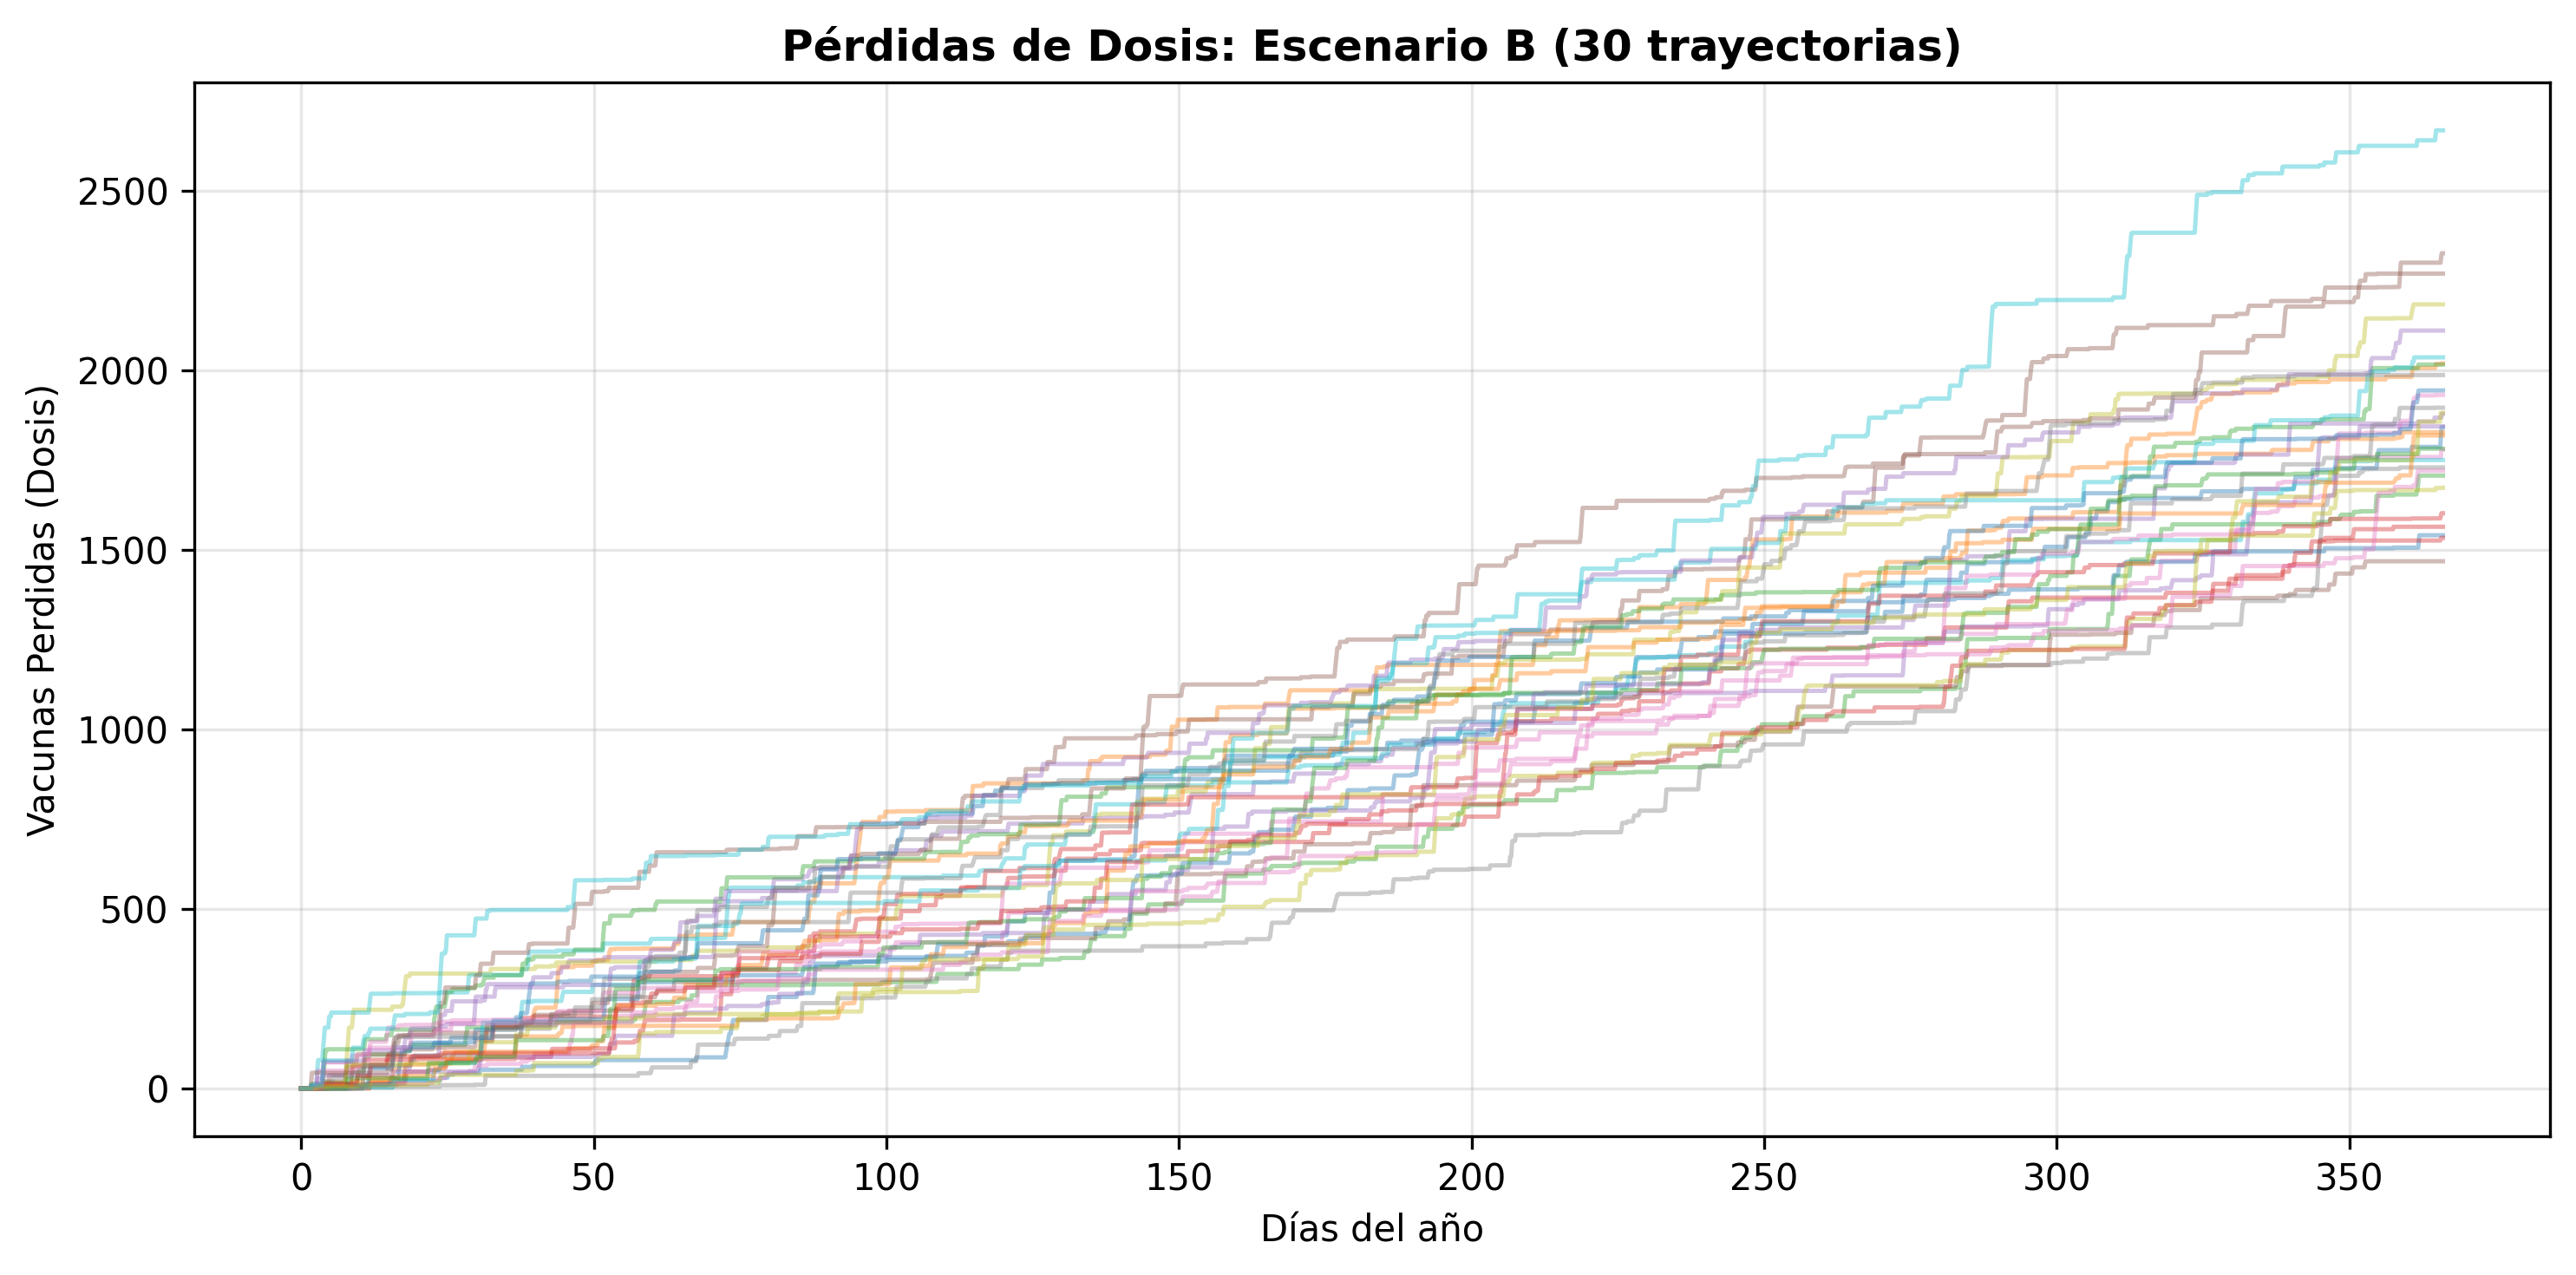

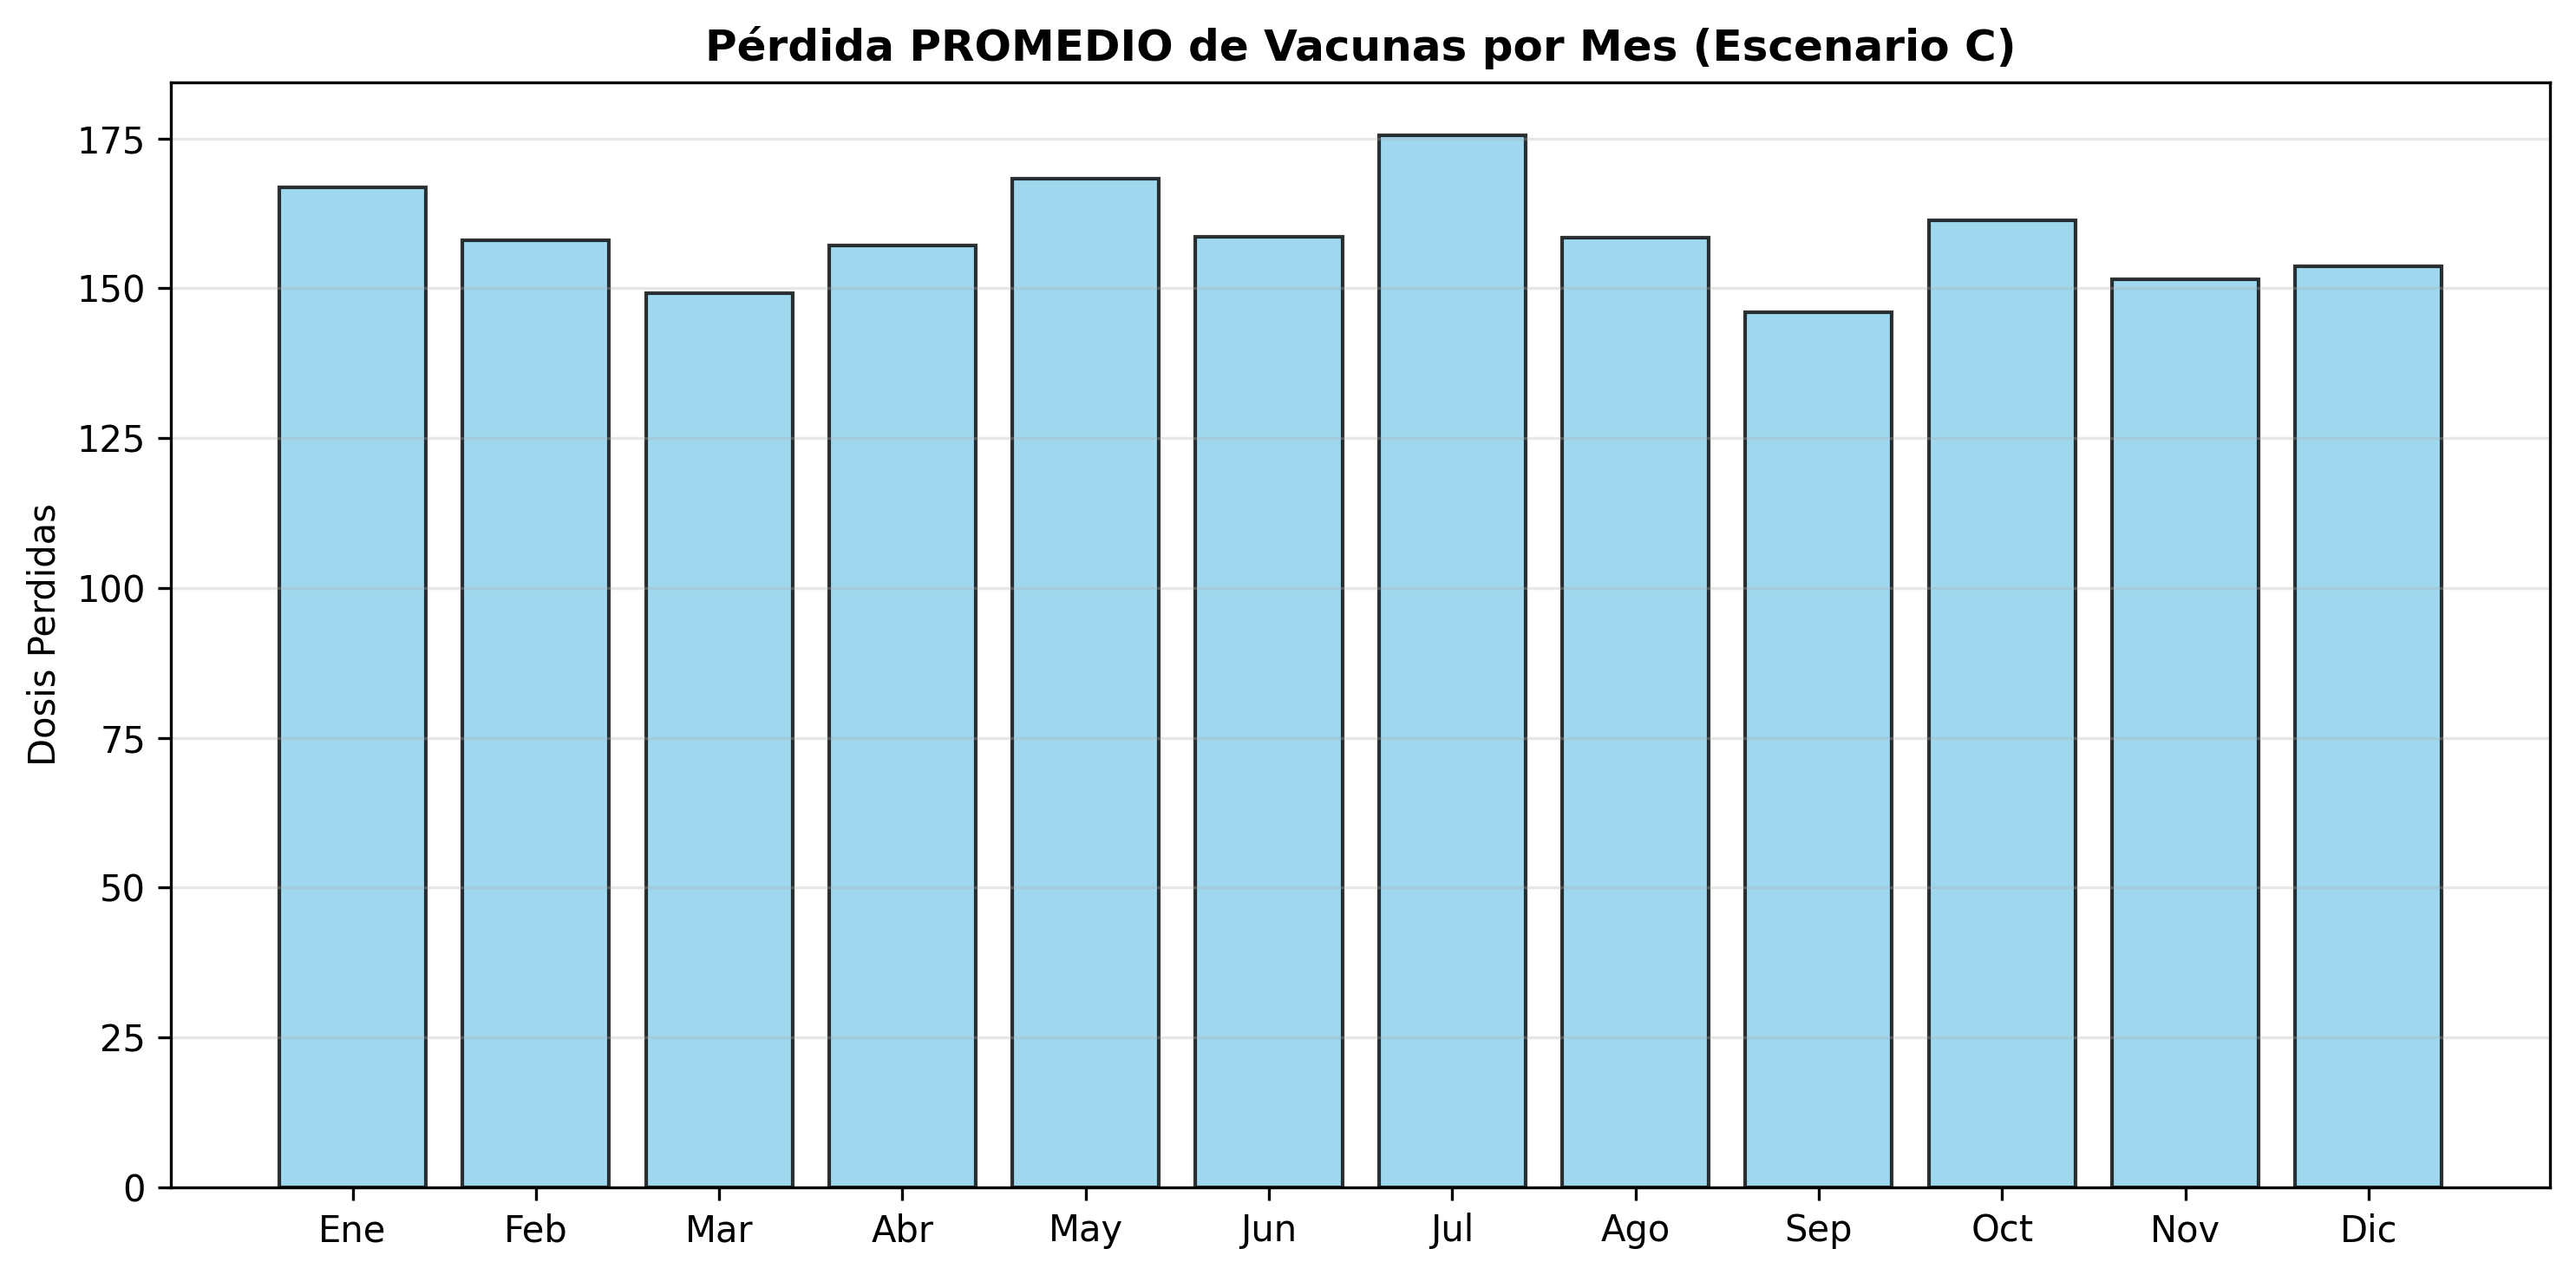

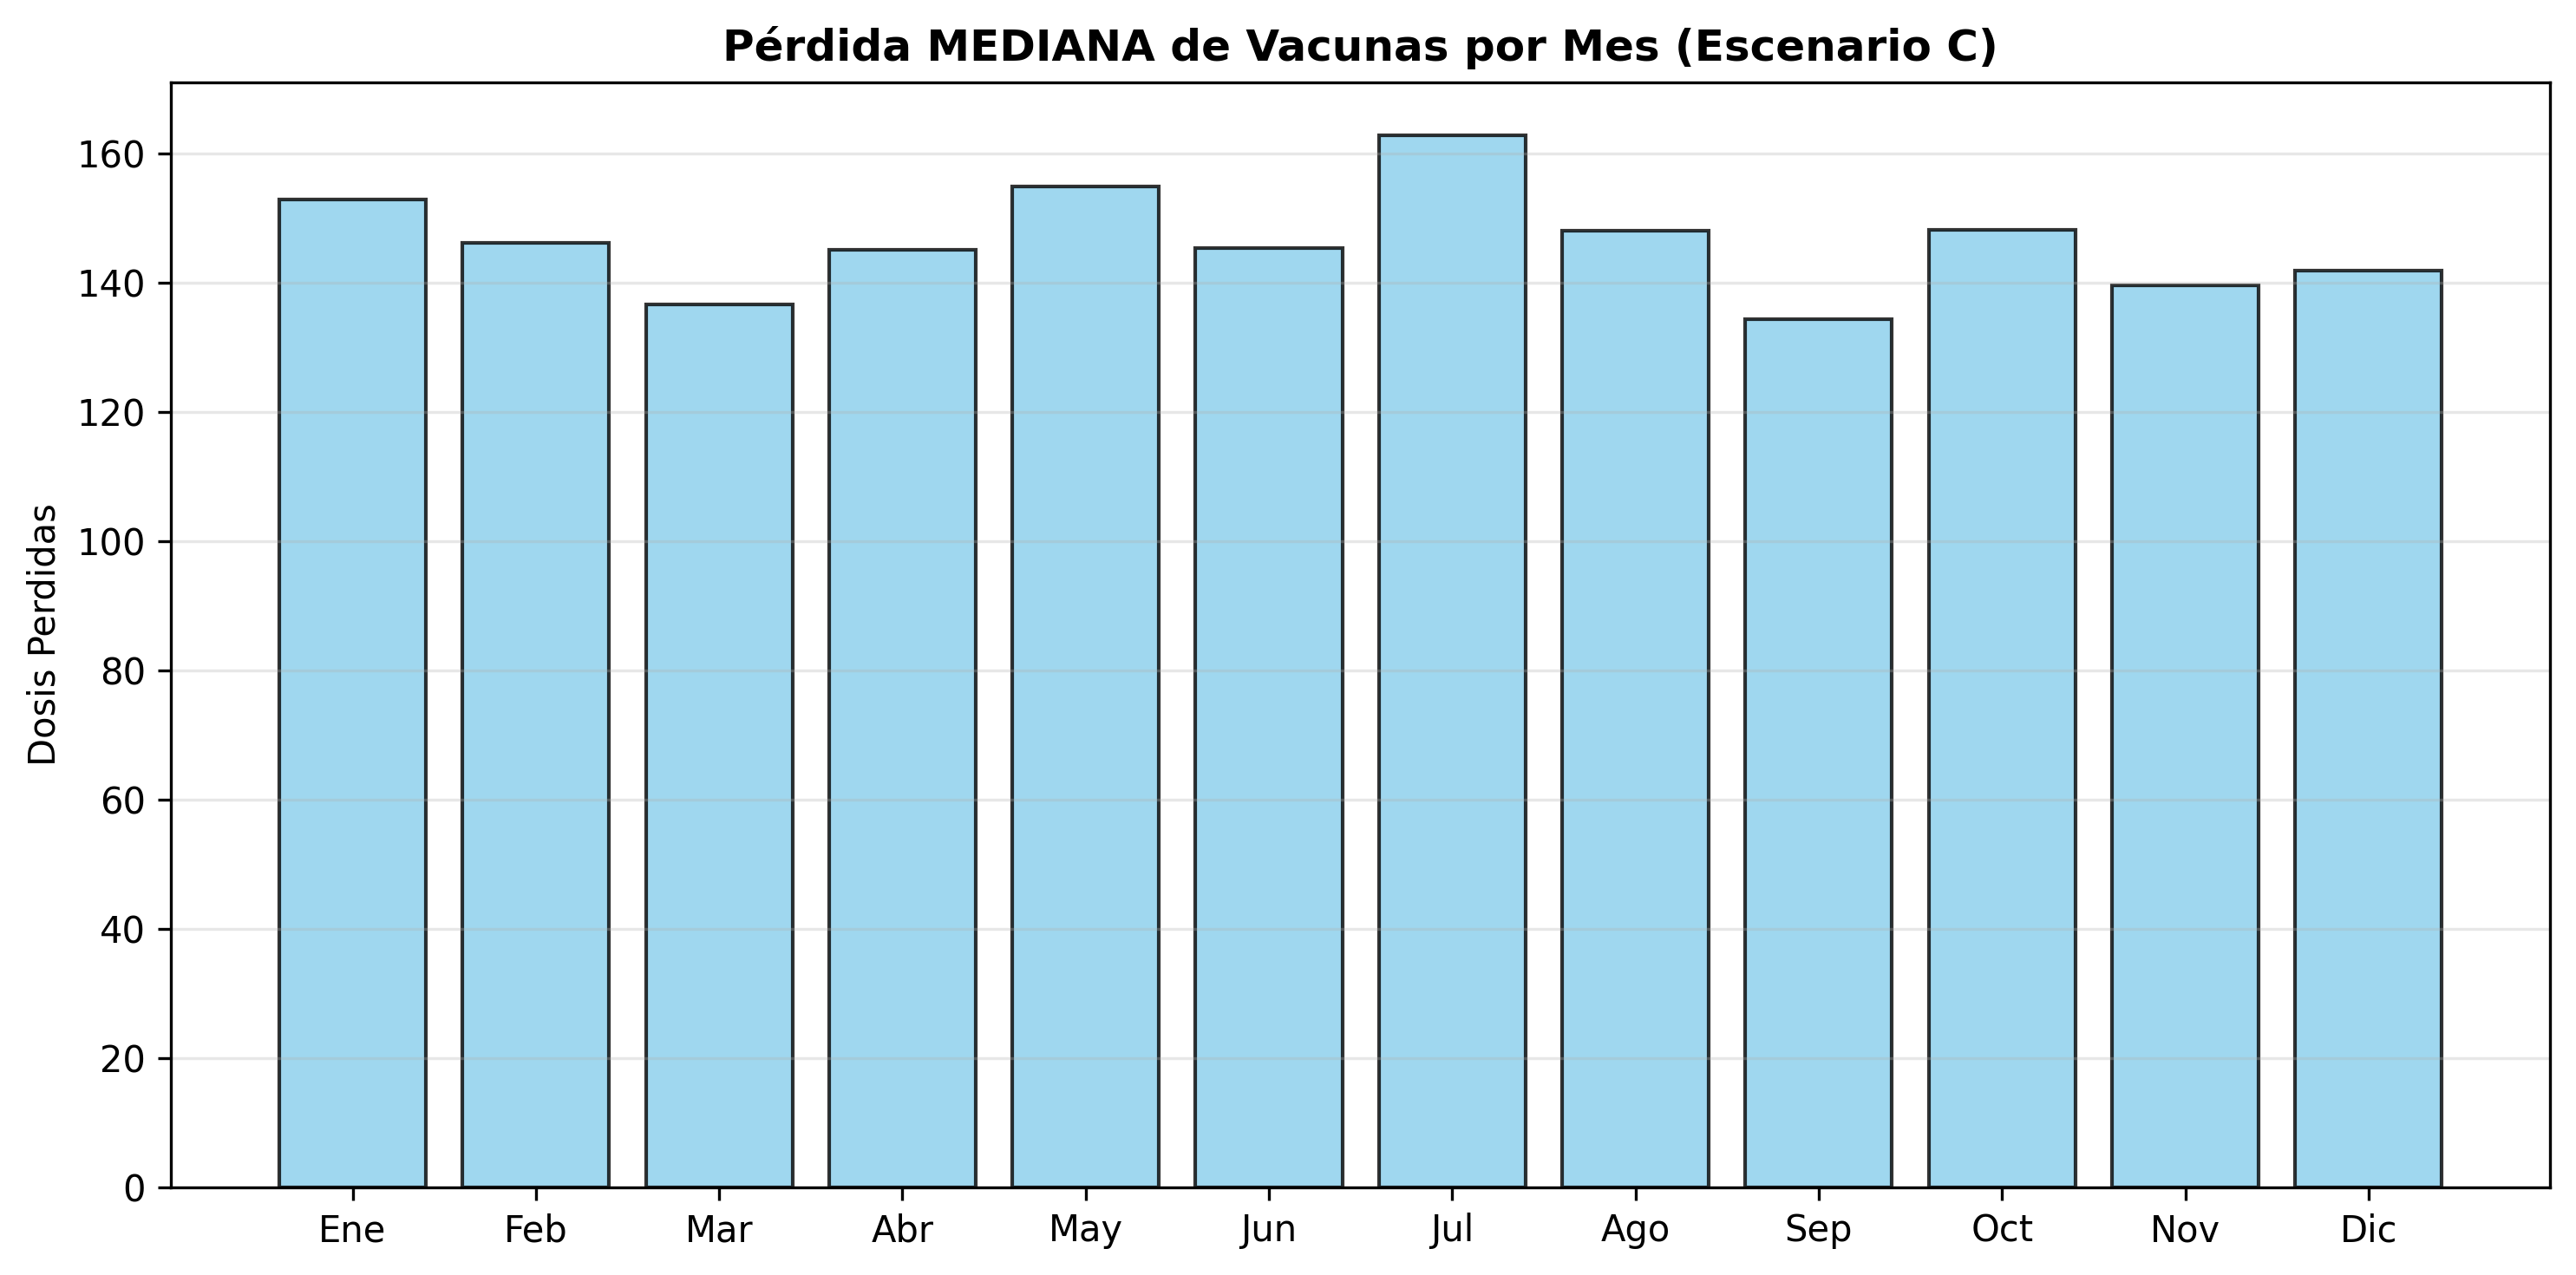

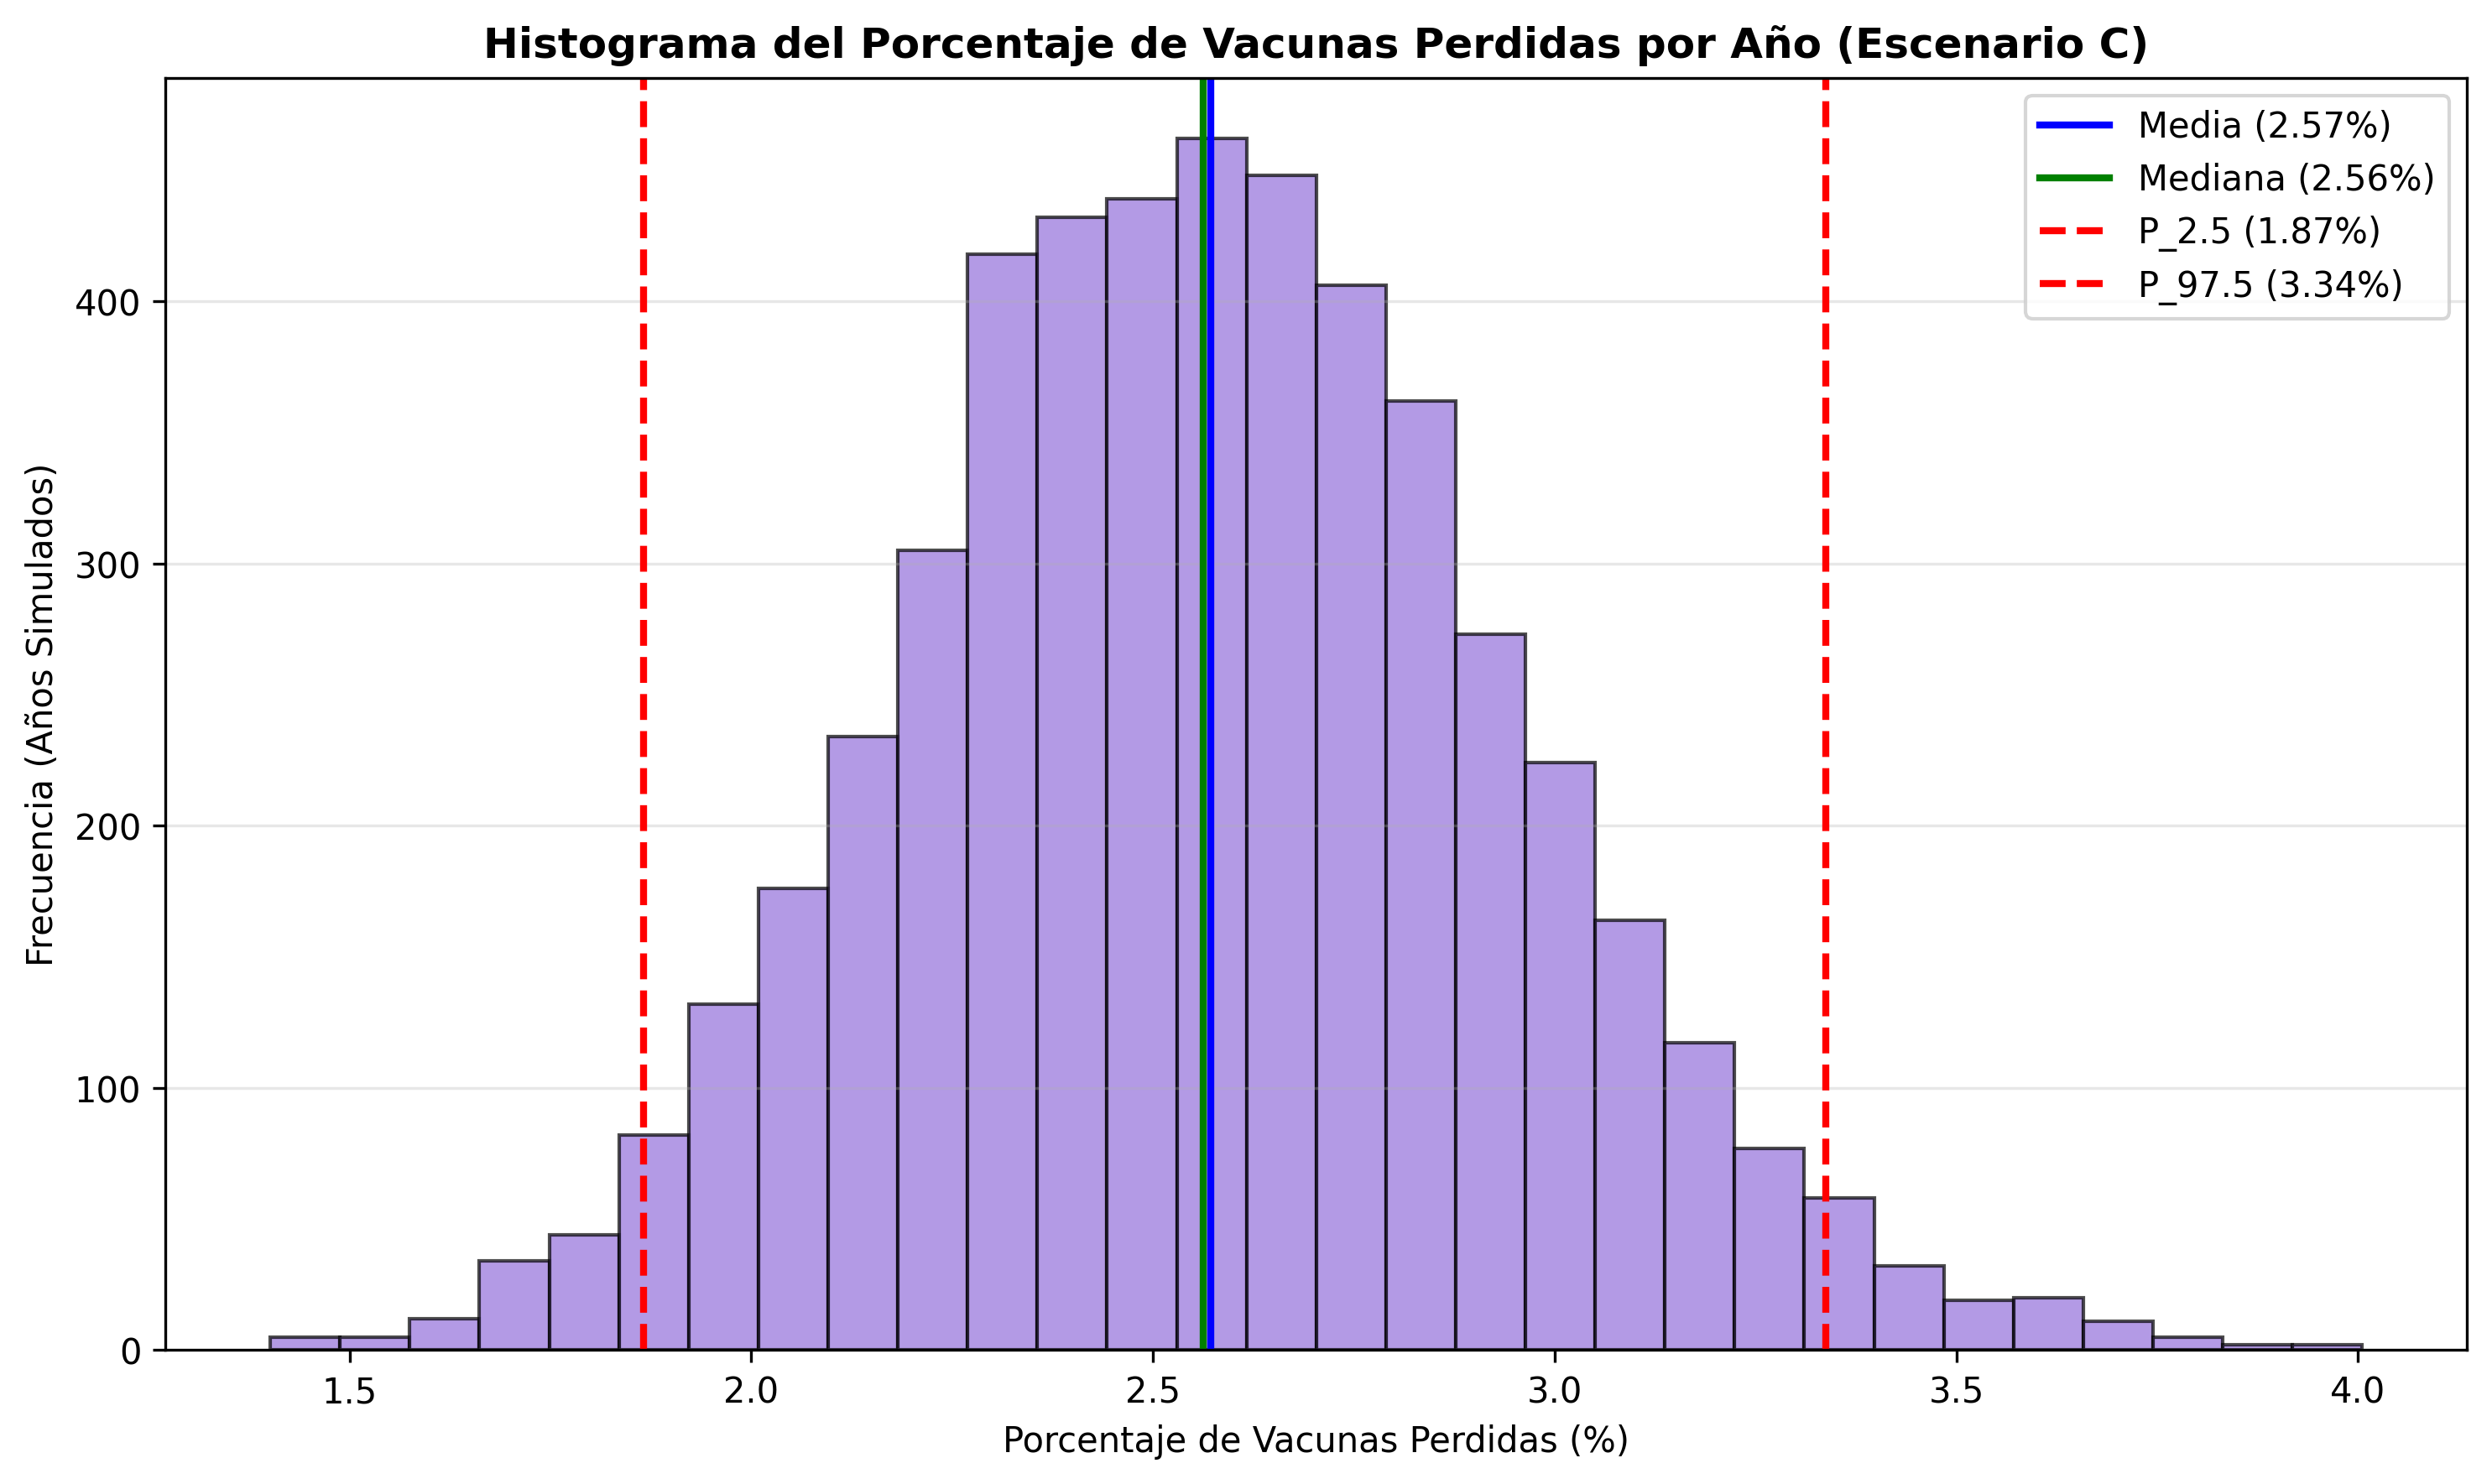

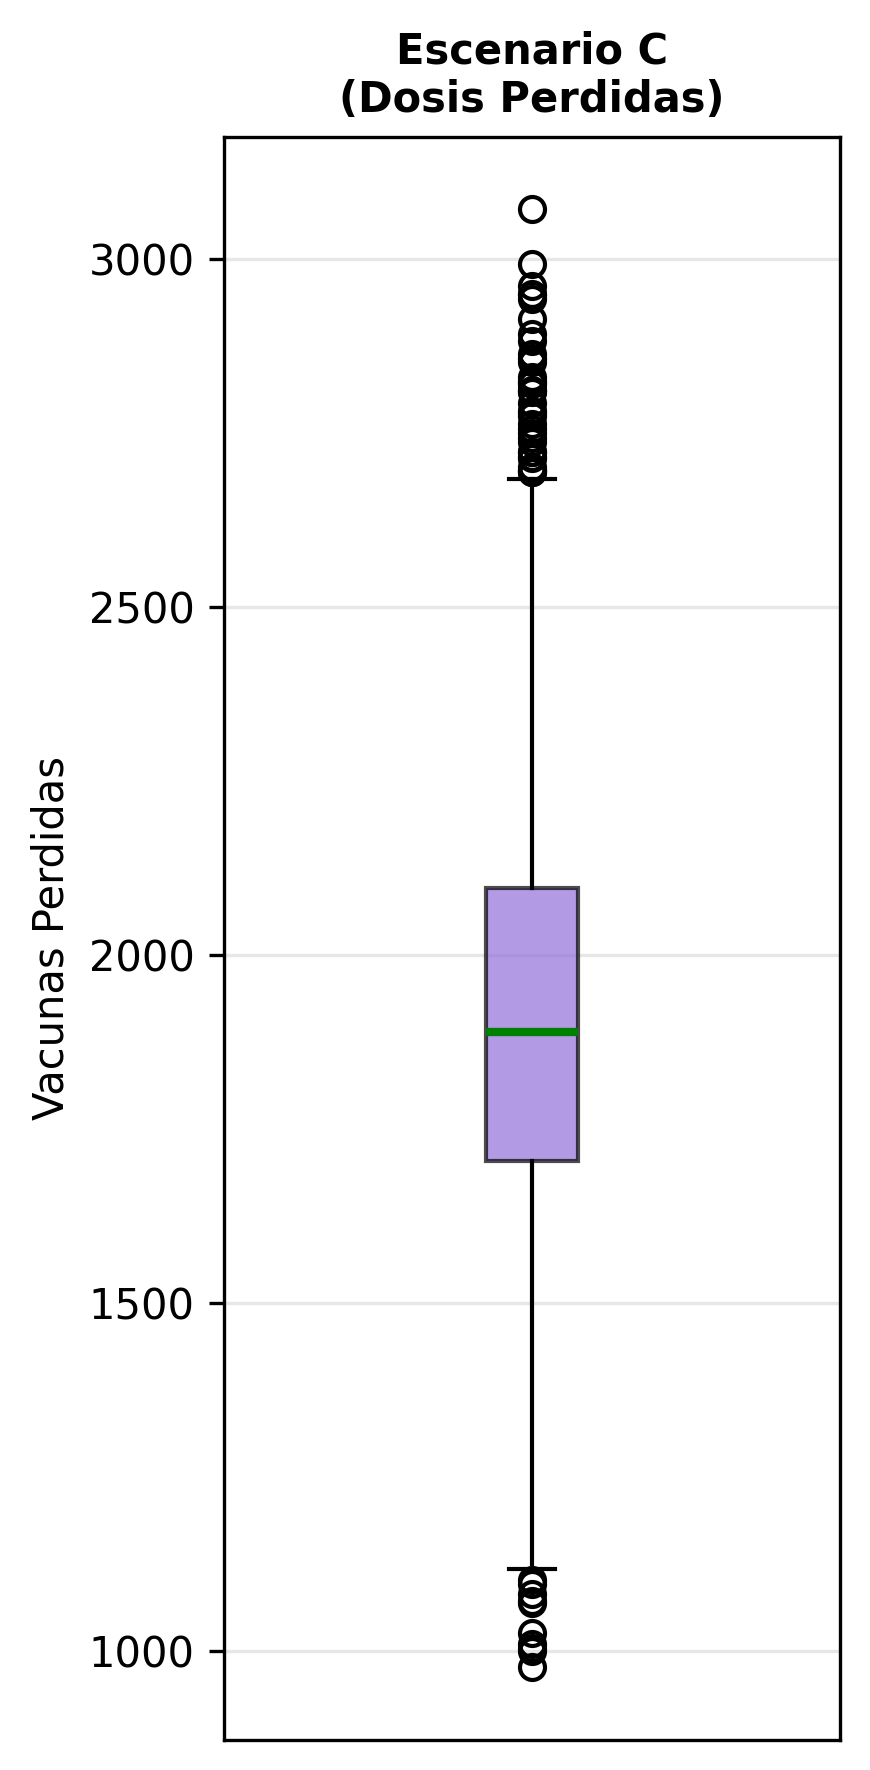

In [ ]:
import warnings
warnings.filterwarnings('ignore') # Ocultar advertencias de medias con arrays vacíos (NaN)

# 1. EXTRAER DATOS A ARREGLOS DE NUMPY
mermas_anuales = np.array([res['merma_anual'] for res in resultados_mc])
dosis_ingresadas = np.array([res['dosis_totales_ingresadas'] for res in resultados_mc])
apagones_anuales = np.array([res['total_apagones'] for res in resultados_mc])
aperturas_anuales = np.array([res['total_aperturas'] for res in resultados_mc])
mermas_mensuales = np.array([res['merma_por_mes'] for res in resultados_mc])

# Termodinámica
horas_8 = np.array([res['horas_8'] for res in resultados_mc])
horas_2 = np.array([res['horas_2'] for res in resultados_mc])
horas_0 = np.array([res['horas_0'] for res in resultados_mc])
ph_8 = np.array([res['porcentaje_horas_8'] for res in resultados_mc])
ph_2 = np.array([res['porcentaje_horas_2'] for res in resultados_mc])
ph_0 = np.array([res['porcentaje_horas_0'] for res in resultados_mc])
ev_8 = np.array([res['eventos_8'] for res in resultados_mc])
ev_2 = np.array([res['eventos_2'] for res in resultados_mc])
ev_0 = np.array([res['eventos_0'] for res in resultados_mc])
dia_8 = np.array([res['primer_dia_8'] for res in resultados_mc])
dia_2 = np.array([res['primer_dia_2'] for res in resultados_mc])
dia_0 = np.array([res['primer_dia_0'] for res in resultados_mc])

porcentajes_perdida = np.array([res['porcentaje_perdida'] for res in resultados_mc])

horas_totales = horas_8 + horas_2
ph_totales = ph_8 + ph_2

# 2. TABLA RESUMEN EN CONSOLA
print("="*75)
print(" TABLA RESUMEN DE RIESGO OPERATIVO Y TERMODINÁMICO (ESCENARIO C) ")
print("="*75)
print(f"Trayectorias Simuladas: {N_SIMULACIONES} años")
print(f"Apagones promedio: {np.mean(apagones_anuales):.1f} por año")
print(f"Aperturas promedio: {np.mean(aperturas_anuales):.0f} por año")
print("-" * 75)
print("MÉTRICAS TERMODINÁMICAS (Excursiones Térmicas)")

print(f"\n -> EXCURSIONES SOBRE 8°C:")
print(f"    Eventos anuales  : Promedio {np.mean(ev_8):.1f} | Mediana {np.median(ev_8):.0f} | Int. 95% [{np.percentile(ev_8, 2.5):.0f}, {np.percentile(ev_8, 97.5):.0f}]")
print(f"    Tiempo acumulado : Promedio {np.mean(horas_8):.1f} h ({np.mean(ph_8):.2f}%) | Mediana {np.median(horas_8):.1f} h ({np.median(ph_8):.2f}%) | Int. 95% [{np.percentile(horas_8, 2.5):.1f} h, {np.percentile(horas_8, 97.5):.1f} h]")
if not np.all(np.isnan(dia_8)):
    print(f"    Primer registro  : Promedio Día {np.nanmean(dia_8):.0f} | Mediana Día {np.nanmedian(dia_8):.0f} | Int. 95% [Día {np.nanpercentile(dia_8, 2.5):.0f}, Día {np.nanpercentile(dia_8, 97.5):.0f}]")

print(f"\n -> EXCURSIONES BAJO 2°C:")
print(f"    Eventos anuales  : Promedio {np.mean(ev_2):.1f} | Mediana {np.median(ev_2):.0f} | Int. 95% [{np.percentile(ev_2, 2.5):.0f}, {np.percentile(ev_2, 97.5):.0f}]")
print(f"    Tiempo acumulado : Promedio {np.mean(horas_2):.1f} h ({np.mean(ph_2):.2f}%) | Mediana {np.median(horas_2):.1f} h ({np.median(ph_2):.2f}%) | Int. 95% [{np.percentile(horas_2, 2.5):.1f} h, {np.percentile(horas_2, 97.5):.1f} h]")
if not np.all(np.isnan(dia_2)):
    print(f"    Primer registro  : Promedio Día {np.nanmean(dia_2):.0f} | Mediana Día {np.nanmedian(dia_2):.0f} | Int. 95% [Día {np.nanpercentile(dia_2, 2.5):.0f}, Día {np.nanpercentile(dia_2, 97.5):.0f}]")

print(f"\n -> CONGELACIÓN (BAJO 0°C):")
print(f"    Eventos anuales  : Promedio {np.mean(ev_0):.1f} | Mediana {np.median(ev_0):.0f} | Int. 95% [{np.percentile(ev_0, 2.5):.0f}, {np.percentile(ev_0, 97.5):.0f}]")
print(f"    Tiempo acumulado : Promedio {np.mean(horas_0):.1f} h ({np.mean(ph_0):.2f}%) | Mediana {np.median(horas_0):.1f} h ({np.median(ph_0):.2f}%) | Int. 95% [{np.percentile(horas_0, 2.5):.1f} h, {np.percentile(horas_0, 97.5):.1f} h]")
if not np.all(np.isnan(dia_0)):
    print(f"    Primer registro  : Promedio Día {np.nanmean(dia_0):.0f} | Mediana Día {np.nanmedian(dia_0):.0f} | Int. 95% [Día {np.nanpercentile(dia_0, 2.5):.0f}, Día {np.nanpercentile(dia_0, 97.5):.0f}]")

print(f"\n => TIEMPO TOTAL FUERA DE RANGO NORMATIVO (>8°C y <2°C):")
print(f"    Tiempo acumulado : Promedio {np.mean(horas_totales):.1f} h ({np.mean(ph_totales):.2f}%) | Mediana {np.median(horas_totales):.1f} h ({np.median(ph_totales):.2f}%) | Int. 95% [{np.percentile(horas_totales, 2.5):.1f} h, {np.percentile(horas_totales, 97.5):.1f} h]")

print("-" * 75)
print("MÉTRICAS LOGÍSTICAS Y DE RIESGO")
print(f" Dosis Perdidas : Promedio {np.mean(mermas_anuales):.0f} | Mediana {np.median(mermas_anuales):.0f} | Int. 95% [{np.percentile(mermas_anuales, 2.5):.0f}, {np.percentile(mermas_anuales, 97.5):.0f}] dosis")
print(f" Merma Relativa : Promedio {np.mean(porcentajes_perdida):.2f}% | Mediana {np.median(porcentajes_perdida):.2f}% | Int. 95% [{np.percentile(porcentajes_perdida, 2.5):.2f}%, {np.percentile(porcentajes_perdida, 97.5):.2f}%]")
print("="*75)

# 3. GRÁFICAS (5 PANELES SEPARADOS)

# --- GRÁFICA 1: TRAYECTORIAS (30) ---
plt.figure(figsize=(10, 5), dpi=300)
trayectorias_a_graficar = 30
for i in range(trayectorias_a_graficar):
    plt.plot(t_horas/24, resultados_mc[i]['trayectoria_merma'], alpha=0.4, linewidth=1.2)
plt.title(f'Pérdidas de Dosis: Escenario B (30 trayectorias)', fontweight='bold')
plt.xlabel('Días del año')
plt.ylabel('Vacunas Perdidas (Dosis)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('abanico_riesgo_escenario_C.png', bbox_inches='tight', dpi=300)
plt.show()

# --- GRÁFICA 2: PROMEDIO MENSUAL DE MERMAS ---
plt.figure(figsize=(10, 5), dpi=300)
meses_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
plt.bar(meses_labels, np.mean(mermas_mensuales, axis=0), color='skyblue', alpha=0.8, edgecolor='black')
plt.title('Pérdida PROMEDIO de Vacunas por Mes (Escenario C)', fontweight='bold')
plt.ylabel('Dosis Perdidas')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('barras_estacionales_promedio_escenario_C.png', bbox_inches='tight', dpi=300)
plt.show()

# --- GRÁFICA 3: MEDIANA MENSUAL DE MERMAS ---
plt.figure(figsize=(10, 5), dpi=300)
plt.bar(meses_labels, np.median(mermas_mensuales, axis=0), color='skyblue', alpha=0.8, edgecolor='black')
plt.title('Pérdida MEDIANA de Vacunas por Mes (Escenario C)', fontweight='bold')
plt.ylabel('Dosis Perdidas')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('barras_estacionales_mediana_escenario_C.png', bbox_inches='tight', dpi=300)
plt.show()

# --- GRÁFICA 4: HISTOGRAMA DE RIESGO ---
plt.figure(figsize=(10, 6), dpi=300)
plt.hist(porcentajes_perdida, bins=30, color='mediumpurple', edgecolor='black', alpha=0.7)
plt.axvline(np.mean(porcentajes_perdida), color='blue', linestyle='-', linewidth=2, label=f'Media ({np.mean(porcentajes_perdida):.2f}%)')
plt.axvline(np.median(porcentajes_perdida), color='green', linestyle='-', linewidth=2, label=f'Mediana ({np.median(porcentajes_perdida):.2f}%)')
plt.axvline(np.percentile(porcentajes_perdida, 2.5), color='red', linestyle='--', linewidth=2, label=f'P_2.5 ({np.percentile(porcentajes_perdida, 2.5):.2f}%)')
plt.axvline(np.percentile(porcentajes_perdida, 97.5), color='red', linestyle='--', linewidth=2, label=f'P_97.5 ({np.percentile(porcentajes_perdida, 97.5):.2f}%)')
plt.title('Histograma del Porcentaje de Vacunas Perdidas por Año (Escenario C)', fontweight='bold')
plt.xlabel('Porcentaje de Vacunas Perdidas (%)')
plt.ylabel('Frecuencia (Años Simulados)')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('histograma_porcentajes_escenario_C.png', bbox_inches='tight', dpi=300)
plt.show()

# --- GRÁFICA 5: BOXPLOT ANGOSTO DE DOSIS PERDIDAS ---
plt.figure(figsize=(3, 6), dpi=300)
plt.boxplot(mermas_anuales, patch_artist=True, boxprops=dict(facecolor='mediumpurple', color='black', alpha=0.7), medianprops=dict(color='green', linewidth=2))
plt.title('Escenario C\n(Dosis Perdidas)', fontweight='bold', fontsize=10)
plt.ylabel('Vacunas Perdidas')
plt.grid(axis='y', alpha=0.3)
plt.xticks([])
plt.tight_layout()
plt.savefig('boxplot_angosto_escenario_C.png', bbox_inches='tight', dpi=300)
plt.show()

## Celda 9: Análisis de Distribuciones y Prueba de Normalidad (Contingencia)

En esta celda evaluamos la naturaleza estadística del riesgo. En el cálculo estocástico, comprender la "forma" de las distribuciones resultantes es tan importante como conocer sus promedios.

Aplicamos la **Prueba de Shapiro-Wilk** a las métricas termodinámicas y logísticas obtenidas del Montecarlo. Esta prueba nos permite evaluar matemáticamente la hipótesis nula ($H_0$) de que los datos provienen de una distribución Normal (Gaussiana).
* Si el **Valor-p < 0.05**, rechazamos $H_0$, concluyendo que la distribución es asimétrica y depende de eventos extremos.
* Si el **Valor-p > 0.05**, no rechazamos $H_0$, lo que sugiere que la variable se ha estabilizado (Teorema del Límite Central).

Este es un análisis crucial: observaremos cómo la saturación de extracciones (alta frecuencia de variables aleatorias) empuja fuertemente la distribución geométrica del riesgo hacia la normalidad, demostrando que bajo estrés operativo, el colapso del sistema deja de ser un "evento raro" para convertirse en un comportamiento determinista estadísticamente.

In [ ]:
import scipy.stats as stats
import pandas as pd

# 1. PREPARACIÓN DE LAS VARIABLES (Filtrando NaNs para las pruebas)
variables_a_testear = {
    "Dosis Perdidas": mermas_anuales,
    "Porcentaje de Merma": porcentajes_perdida,
    "Eventos > 8°C": ev_8,
    "Horas Acumuladas > 8°C": horas_8,
    "Primer Día > 8°C": dia_8[~np.isnan(dia_8)],
    "Eventos < 2°C": ev_2,
    "Horas Acumuladas < 2°C": horas_2,
    "Primer Día < 2°C": dia_2[~np.isnan(dia_2)],
    "Eventos < 0°C": ev_0,
    "Horas Acumuladas < 0°C": horas_0,
    "Primer Día < 0°C": dia_0[~np.isnan(dia_0)],
    "Tiempo Total Fuera de Rango": horas_totales
}

resultados_test = []

# 2. PRUEBA DE SHAPIRO-WILK
for nombre, data in variables_a_testear.items():
    # Solo aplicamos el test si hay datos suficientes y la varianza no es cero
    if len(data) >= 3 and np.var(data) > 0:
        stat, p_value = stats.shapiro(data)
        # Nivel de significancia alfa = 0.05
        es_normal = "Sí (No se rechaza H0)" if p_value > 0.05 else "No (Se rechaza H0)"
    else:
        stat, p_value = np.nan, np.nan
        es_normal = "No evaluable (Constante o Vacío)"

    resultados_test.append({
        "Métrica": nombre,
        "Estadístico W": stat,
        "Valor-p": p_value,
        "¿Distribución Normal?": es_normal
    })

# 3. IMPRESIÓN DE LA TABLA
df_normalidad = pd.DataFrame(resultados_test)

print("="*85)
print(" PRUEBA DE NORMALIDAD DE SHAPIRO-WILK (ESCENARIO C) ")
print("="*85)
print(df_normalidad.to_string(index=False, float_format=lambda x: f"{x:.4e}" if pd.notnull(x) else "N/A"))
print("="*85)
print("* Nivel de significancia (α) = 0.05")

 PRUEBA DE NORMALIDAD DE SHAPIRO-WILK (ESCENARIO C) 
                    Métrica  Estadístico W    Valor-p ¿Distribución Normal?
             Dosis Perdidas     9.9712e-01 3.4578e-08    No (Se rechaza H0)
        Porcentaje de Merma     9.9800e-01 4.5176e-06    No (Se rechaza H0)
              Eventos > 8°C     9.9931e-01 4.9186e-02    No (Se rechaza H0)
     Horas Acumuladas > 8°C     9.9869e-01 4.5979e-04    No (Se rechaza H0)
           Primer Día > 8°C     7.4511e-01 2.9458e-66    No (Se rechaza H0)
              Eventos < 2°C     9.3901e-01 2.9725e-41    No (Se rechaza H0)
     Horas Acumuladas < 2°C     8.6825e-01 5.8070e-54    No (Se rechaza H0)
           Primer Día < 2°C     8.7533e-01 1.8365e-52    No (Se rechaza H0)
              Eventos < 0°C     1.2999e-02 1.5261e-95    No (Se rechaza H0)
     Horas Acumuladas < 0°C     5.1327e-03 9.9024e-96    No (Se rechaza H0)
           Primer Día < 0°C     9.0826e-01 3.8397e-01 Sí (No se rechaza H0)
Tiempo Total Fuera de Rango     9.9

## Celda 10: Remuestreo Bootstrap y Análisis No Paramétrico (Apego Normativo)

Debido a que la prueba de Shapiro-Wilk rechazó la normalidad de nuestras distribuciones de riesgo (las cuales presentan asimetría y colas pesadas por los eventos extremos), la estadística inferencial clásica no es aplicable.

Para resolver esto de forma rigurosa, implementamos el método no paramétrico de **Bootstrap**.
1. **Remuestreo:** Extraemos 10,000 muestras aleatorias (con reemplazo) a partir de nuestros 5,000 años simulados.
2. **Intervalos de Confianza:** Por el Teorema del Límite Central, la distribución de estas 10,000 medias muestrales convergerá a una distribución Normal perfecta. Esto nos permite extraer el Intervalo de Confianza al 95% para afirmar con absoluta certeza matemática el impacto del apego normativo en el centro de almacenamiento para vacunas.
3. **Visualización Estabilizada:** Generaremos el histograma de las medias (para validar visualmente la normalidad del estimador) y un *boxplot* de las medias, demostrando cómo se reduce drásticamente la incertidumbre de los datos atípicos y se aísla el verdadero riesgo operativo.

Ejecutando remuestreo Bootstrap (10000 iteraciones)...
Bootstrap completado en 5.48 segundos.

 TABLA INFERENCIAL BOOTSTRAP: PROMEDIOS ESPERADOS E INTERVALOS AL 95% (ESCENARIO C) 
 -> EXCURSIONES SOBRE 8°C:
    Eventos anuales  : Promedio 419.7 | Mediana 419 | Int. Conf 95% [418.5, 420.8]
    Tiempo acumulado : Promedio 416.5 h (4.74%) | Mediana 415.1 h (4.73%) | Int. Conf 95% [415.1 h (4.73%), 417.9 h (4.76%)]
    Primer registro  : Promedio Día 3 | Mediana Día 2 | Int. Conf 95% [Día 3, Día 3]

 -> EXCURSIONES BAJO 2°C:
    Eventos anuales  : Promedio 9.0 | Mediana 8 | Int. Conf 95% [8.8, 9.2]
    Tiempo acumulado : Promedio 4.1 h (0.05%) | Mediana 3.2 h (0.04%) | Int. Conf 95% [4.0 h (0.05%), 4.2 h (0.05%)]
    Primer registro  : Promedio Día 91 | Mediana Día 67 | Int. Conf 95% [Día 89, Día 94]

 -> CONGELACIÓN (BAJO 0°C):
    Años con eventos : El biológico se congeló en 7 de los 5000 años simulados (0.14%)
    Eventos anuales  : Promedio 0.00 | Mediana 0 | Int. Conf 95% [0.00, 0.00

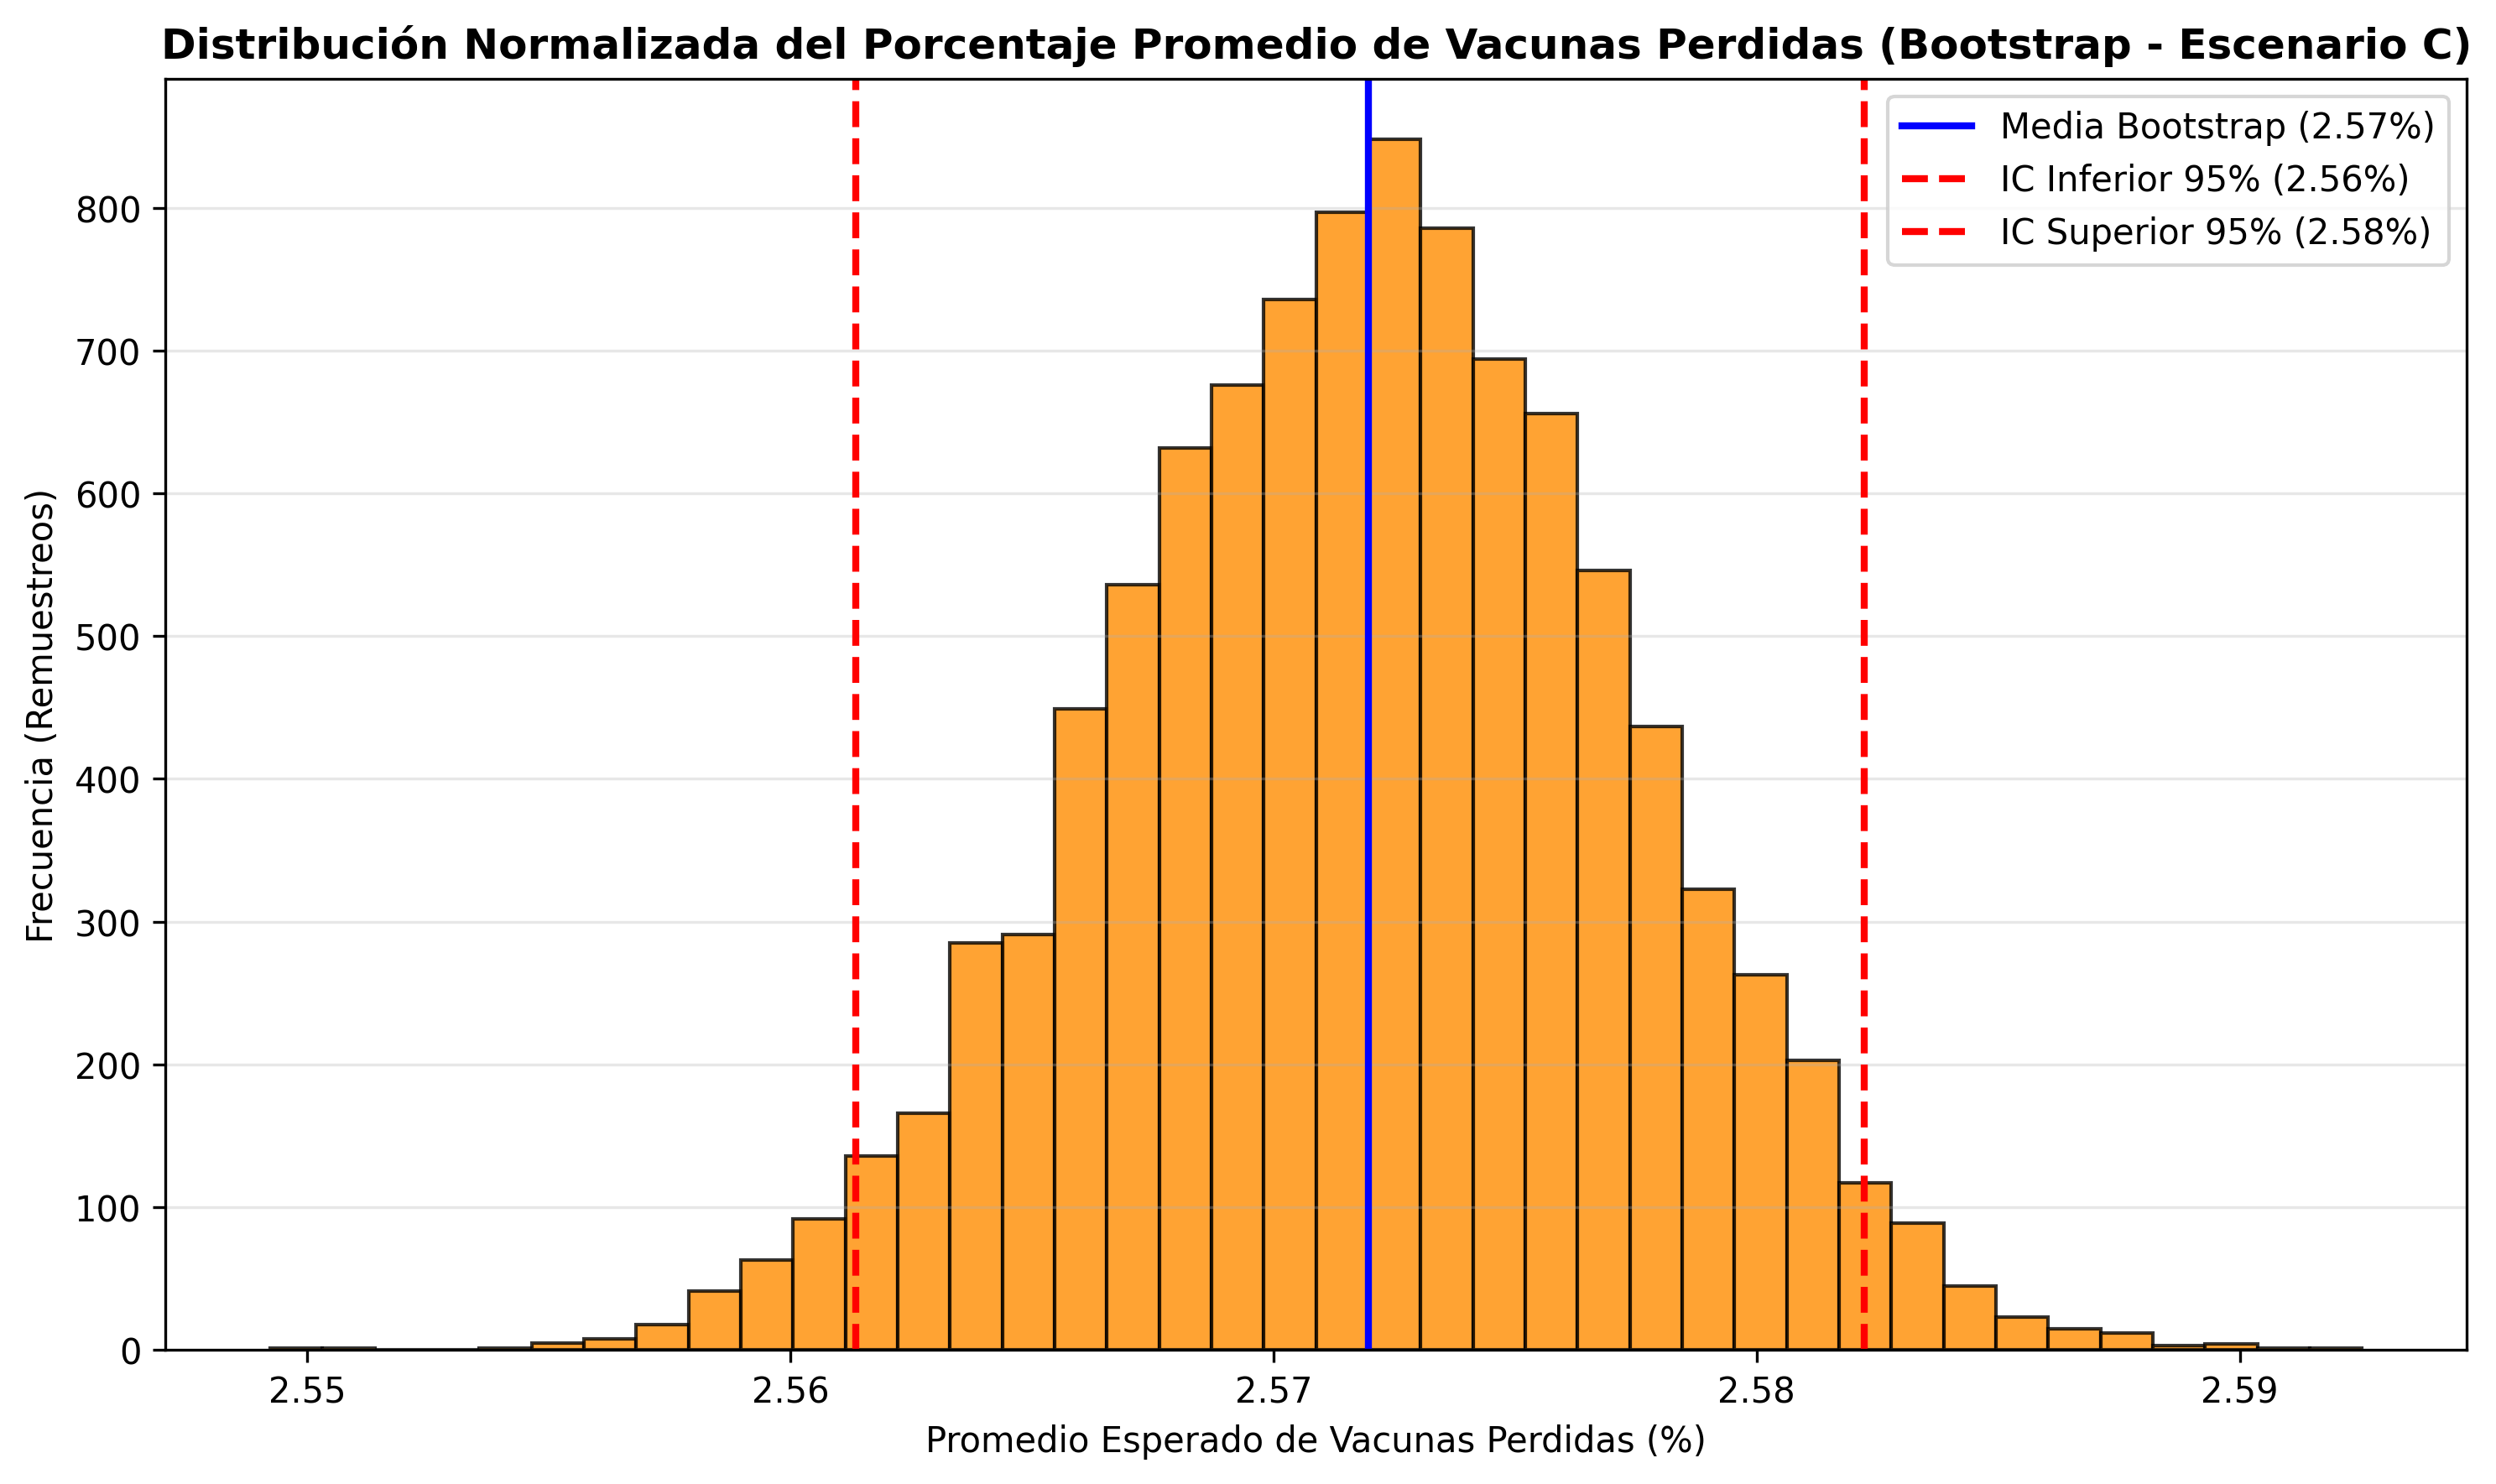

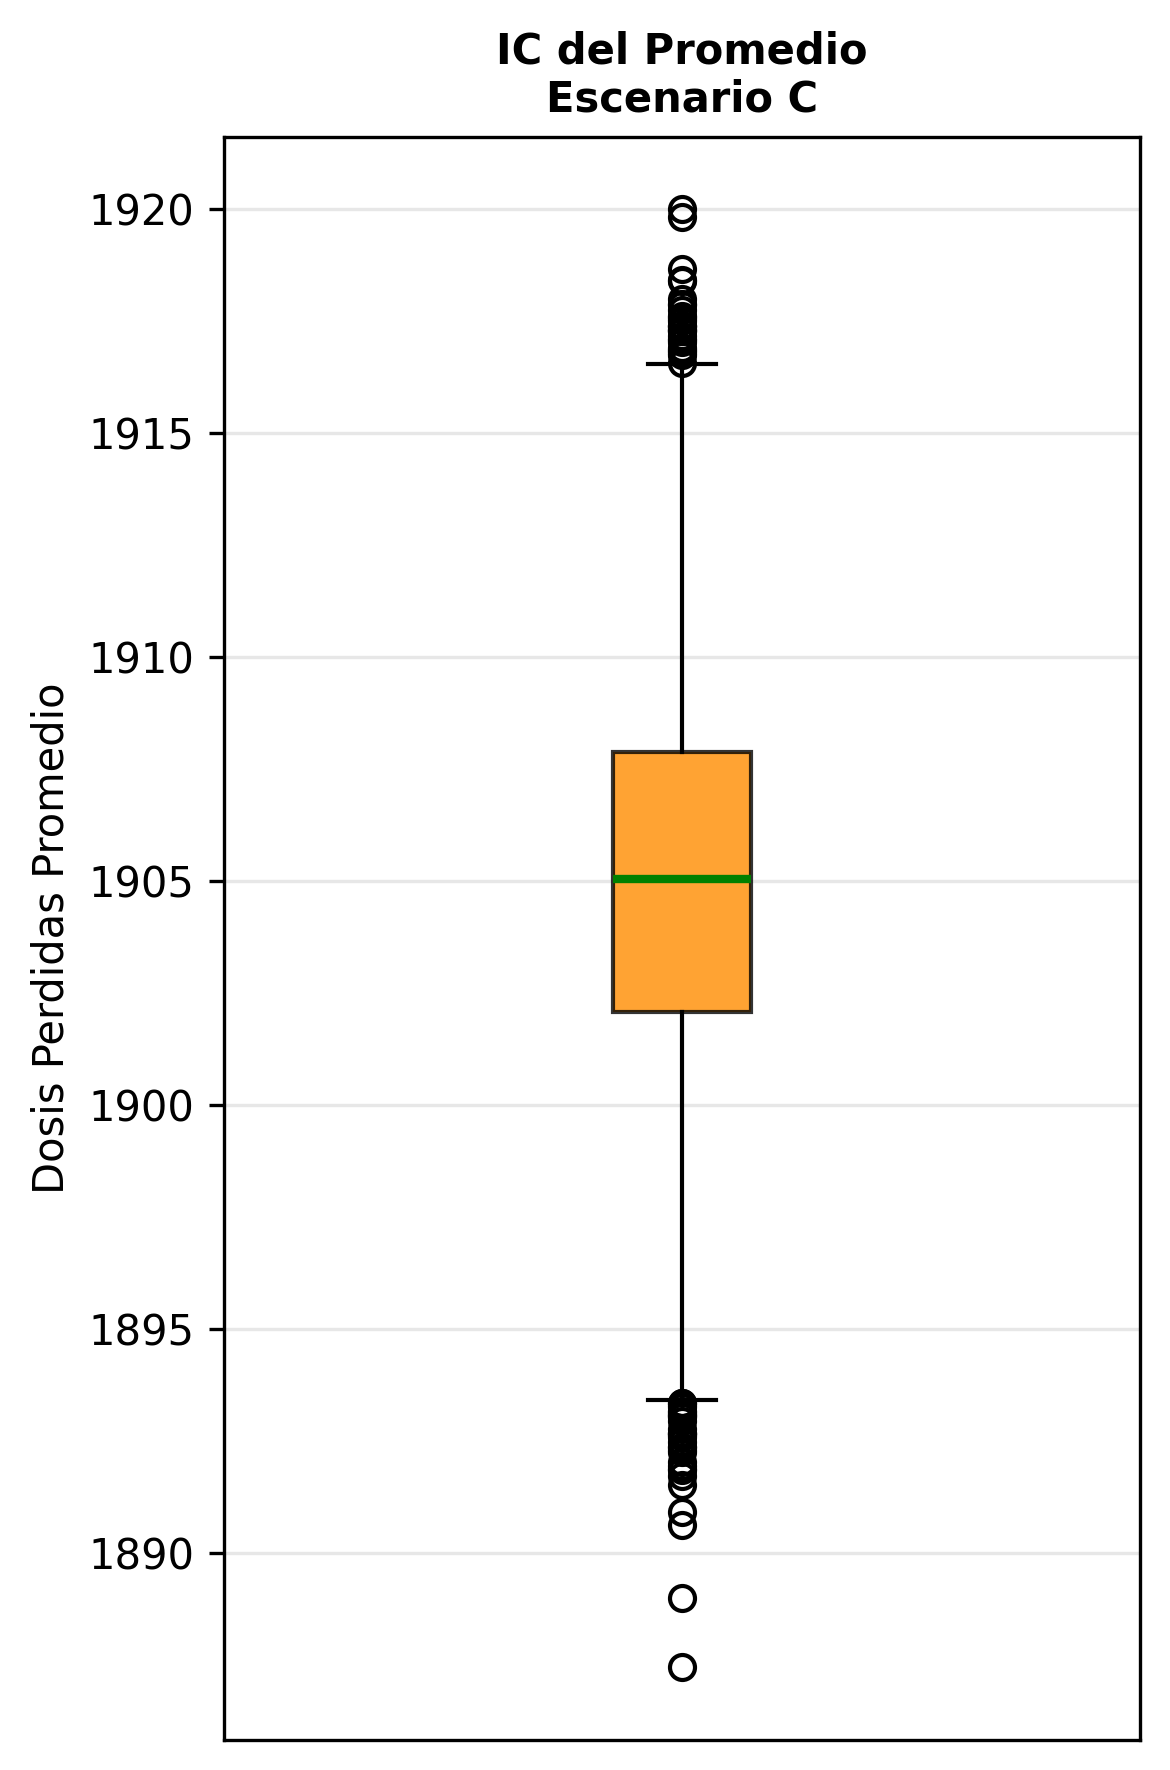

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings

# 1. PREPARACIÓN DEL BOOTSTRAP
np.random.seed(42)
N_BOOT = 10000
n_size = len(mermas_anuales)

print(f"Ejecutando remuestreo Bootstrap ({N_BOOT} iteraciones)...")
inicio_boot = time.time()

# Remuestreo vectorizado (Extremadamente rápido)
idx = np.random.randint(0, n_size, (N_BOOT, n_size))

# 2. CÁLCULO DE MEDIAS BOOTSTRAP
boot_ev_8 = np.mean(ev_8[idx], axis=1)
boot_h_8 = np.mean(horas_8[idx], axis=1)
boot_ph_8 = np.mean(ph_8[idx], axis=1)

boot_ev_2 = np.mean(ev_2[idx], axis=1)
boot_h_2 = np.mean(horas_2[idx], axis=1)
boot_ph_2 = np.mean(ph_2[idx], axis=1)

boot_ev_0 = np.mean(ev_0[idx], axis=1)
boot_h_0 = np.mean(horas_0[idx], axis=1)
boot_ph_0 = np.mean(ph_0[idx], axis=1)

boot_htot = np.mean(horas_totales[idx], axis=1)
boot_phtot = np.mean(ph_totales[idx], axis=1)

boot_mermas = np.mean(mermas_anuales[idx], axis=1)
boot_pct_perdida = np.mean(porcentajes_perdida[idx], axis=1)

# Para los días (ignoramos NaNs de los años donde no hubo fallas)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    boot_dia_8 = np.nanmean(dia_8[idx], axis=1)
    boot_dia_2 = np.nanmean(dia_2[idx], axis=1)
    boot_dia_0 = np.nanmean(dia_0[idx], axis=1)

print(f"Bootstrap completado en {time.time() - inicio_boot:.2f} segundos.\n")

# 3. TABLA DE RESULTADOS INFERENCIALES (INTERVALOS DE CONFIANZA 95%)
anos_congelacion = np.sum(ev_0 > 0)

print("="*85)
print(" TABLA INFERENCIAL BOOTSTRAP: PROMEDIOS ESPERADOS E INTERVALOS AL 95% (ESCENARIO C) ")
print("="*85)

print(f" -> EXCURSIONES SOBRE 8°C:")
print(f"    Eventos anuales  : Promedio {np.mean(ev_8):.1f} | Mediana {np.median(ev_8):.0f} | Int. Conf 95% [{np.percentile(boot_ev_8, 2.5):.1f}, {np.percentile(boot_ev_8, 97.5):.1f}]")
print(f"    Tiempo acumulado : Promedio {np.mean(horas_8):.1f} h ({np.mean(ph_8):.2f}%) | Mediana {np.median(horas_8):.1f} h ({np.median(ph_8):.2f}%) | Int. Conf 95% [{np.percentile(boot_h_8, 2.5):.1f} h ({np.percentile(boot_ph_8, 2.5):.2f}%), {np.percentile(boot_h_8, 97.5):.1f} h ({np.percentile(boot_ph_8, 97.5):.2f}%)]")
if not np.all(np.isnan(dia_8)):
    print(f"    Primer registro  : Promedio Día {np.nanmean(dia_8):.0f} | Mediana Día {np.nanmedian(dia_8):.0f} | Int. Conf 95% [Día {np.nanpercentile(boot_dia_8, 2.5):.0f}, Día {np.nanpercentile(boot_dia_8, 97.5):.0f}]")

print(f"\n -> EXCURSIONES BAJO 2°C:")
print(f"    Eventos anuales  : Promedio {np.mean(ev_2):.1f} | Mediana {np.median(ev_2):.0f} | Int. Conf 95% [{np.percentile(boot_ev_2, 2.5):.1f}, {np.percentile(boot_ev_2, 97.5):.1f}]")
print(f"    Tiempo acumulado : Promedio {np.mean(horas_2):.1f} h ({np.mean(ph_2):.2f}%) | Mediana {np.median(horas_2):.1f} h ({np.median(ph_2):.2f}%) | Int. Conf 95% [{np.percentile(boot_h_2, 2.5):.1f} h ({np.percentile(boot_ph_2, 2.5):.2f}%), {np.percentile(boot_h_2, 97.5):.1f} h ({np.percentile(boot_ph_2, 97.5):.2f}%)]")
if not np.all(np.isnan(dia_2)):
    print(f"    Primer registro  : Promedio Día {np.nanmean(dia_2):.0f} | Mediana Día {np.nanmedian(dia_2):.0f} | Int. Conf 95% [Día {np.nanpercentile(boot_dia_2, 2.5):.0f}, Día {np.nanpercentile(boot_dia_2, 97.5):.0f}]")

print(f"\n -> CONGELACIÓN (BAJO 0°C):")
print(f"    Años con eventos : El biológico se congeló en {anos_congelacion} de los {n_size} años simulados ({(anos_congelacion/n_size)*100:.2f}%)")
print(f"    Eventos anuales  : Promedio {np.mean(ev_0):.2f} | Mediana {np.median(ev_0):.0f} | Int. Conf 95% [{np.percentile(boot_ev_0, 2.5):.2f}, {np.percentile(boot_ev_0, 97.5):.2f}]")
print(f"    Tiempo acumulado : Promedio {np.mean(horas_0):.2f} h ({np.mean(ph_0):.3f}%) | Mediana {np.median(horas_0):.1f} h ({np.median(ph_0):.2f}%) | Int. Conf 95% [{np.percentile(boot_h_0, 2.5):.2f} h ({np.percentile(boot_ph_0, 2.5):.3f}%), {np.percentile(boot_h_0, 97.5):.2f} h ({np.percentile(boot_ph_0, 97.5):.3f}%)]")
if not np.all(np.isnan(dia_0)):
    print(f"    Primer registro  : Promedio Día {np.nanmean(dia_0):.0f} | Mediana Día {np.nanmedian(dia_0):.0f} | Int. Conf 95% [Día {np.nanpercentile(boot_dia_0, 2.5):.0f}, Día {np.nanpercentile(boot_dia_0, 97.5):.0f}]")

print(f"\n => TIEMPO TOTAL FUERA DE RANGO NORMATIVO (>8°C y <2°C):")
print(f"    Tiempo acumulado : Promedio {np.mean(horas_totales):.1f} h ({np.mean(ph_totales):.2f}%) | Mediana {np.median(horas_totales):.1f} h ({np.median(ph_totales):.2f}%) | Int. Conf 95% [{np.percentile(boot_htot, 2.5):.1f} h ({np.percentile(boot_phtot, 2.5):.2f}%), {np.percentile(boot_htot, 97.5):.1f} h ({np.percentile(boot_phtot, 97.5):.2f}%)]")

print("-" * 85)
print("MÉTRICAS LOGÍSTICAS Y DE RIESGO")
print(f" Dosis Perdidas : Promedio {np.mean(mermas_anuales):.0f} | Mediana {np.median(mermas_anuales):.0f} | Int. Conf 95% [{np.percentile(boot_mermas, 2.5):.0f}, {np.percentile(boot_mermas, 97.5):.0f}] dosis")
print(f" Merma Relativa : Promedio {np.mean(porcentajes_perdida):.2f}% | Mediana {np.median(porcentajes_perdida):.2f}% | Int. Conf 95% [{np.percentile(boot_pct_perdida, 2.5):.2f}%, {np.percentile(boot_pct_perdida, 97.5):.2f}%]")
print("="*85)

# 4. GRÁFICAS DE LOS ESTIMADORES (NORMALIZADOS POR TLC)

# --- GRÁFICA 1: HISTOGRAMA BOOTSTRAP DEL PORCENTAJE ---
plt.figure(figsize=(10, 6), dpi=300)
plt.hist(boot_pct_perdida, bins=40, color='darkorange', edgecolor='black', alpha=0.8)
plt.axvline(np.mean(boot_pct_perdida), color='blue', linestyle='-', linewidth=2, label=f'Media Bootstrap ({np.mean(boot_pct_perdida):.2f}%)')
plt.axvline(np.percentile(boot_pct_perdida, 2.5), color='red', linestyle='--', linewidth=2, label=f'IC Inferior 95% ({np.percentile(boot_pct_perdida, 2.5):.2f}%)')
plt.axvline(np.percentile(boot_pct_perdida, 97.5), color='red', linestyle='--', linewidth=2, label=f'IC Superior 95% ({np.percentile(boot_pct_perdida, 97.5):.2f}%)')

plt.title('Distribución Normalizada del Porcentaje Promedio de Vacunas Perdidas (Bootstrap - Escenario C)', fontweight='bold')
plt.xlabel('Promedio Esperado de Vacunas Perdidas (%)')
plt.ylabel('Frecuencia (Remuestreos)')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('histograma_bootstrap_escenario_C.png', bbox_inches='tight', dpi=300)
plt.show()

# --- GRÁFICA 2: BOXPLOT BOOTSTRAP DE DOSIS PERDIDAS ---
plt.figure(figsize=(4, 6), dpi=300)
plt.boxplot(boot_mermas, patch_artist=True, boxprops=dict(facecolor='darkorange', color='black', alpha=0.8), medianprops=dict(color='green', linewidth=2))
plt.title('IC del Promedio\nEscenario C', fontweight='bold', fontsize=10)
plt.ylabel('Dosis Perdidas Promedio')
plt.grid(axis='y', alpha=0.3)
plt.xticks([])
plt.tight_layout()
plt.savefig('boxplot_bootstrap_escenario_C.png', bbox_inches='tight', dpi=300)
plt.show()